In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import transforms
import seaborn as sns
import pandas as pd
import geopandas as gpd
import folium
import requests
from branca.colormap import linear
import textwrap
from folium.plugins import HeatMap
from IPython.display import display, HTML

In [2]:
df = pd.read_csv("./dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,...,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,...,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,...,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,...,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,...,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [3]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

In [5]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype(str).str.strip().str.lower()
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.notna().sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,...,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,...,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


**Overview Fungsi**

Text(0.5, 1.05, 'Feature Correlation')

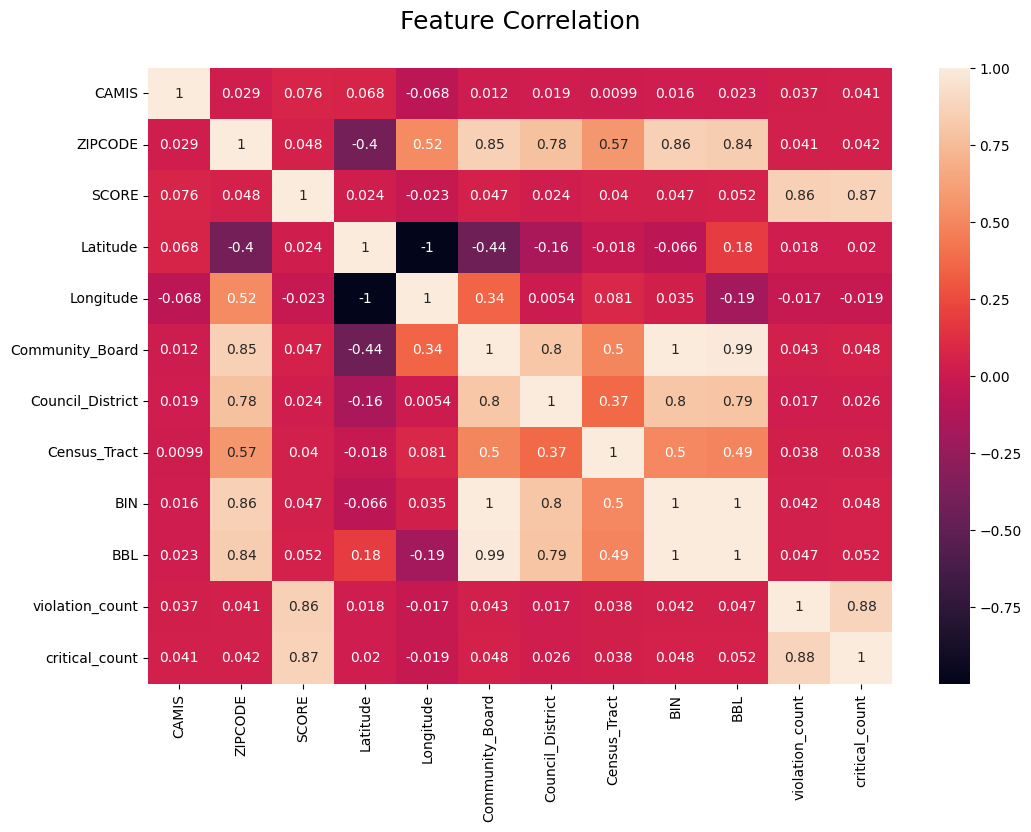

In [6]:
plt.figure(figsize=(12,8))
num_feature = df_ins.select_dtypes(include=['number'])
sns.heatmap(num_feature.corr(), annot=True, cmap="rocket")
plt.title('Feature Correlation', fontsize=18, y=1.05)

**Penjelasan:** Tidak semua fitur perlu digunakan karena ada beberapa fitur yang mengalami redundan

**Distribusi Score**

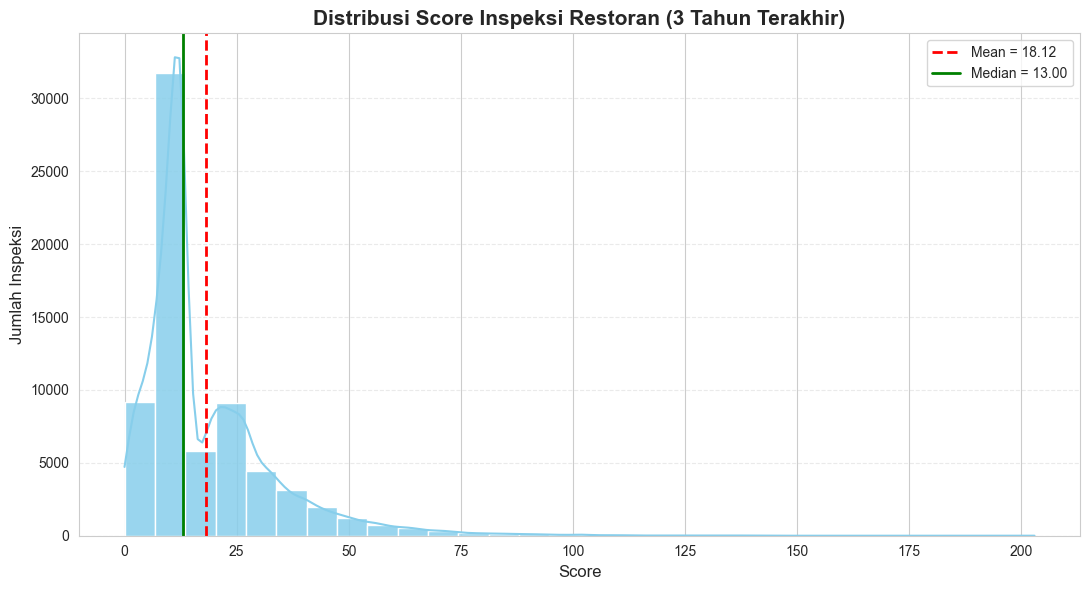

In [7]:
score_data = df_ins["SCORE"].dropna()

mean_score = score_data.mean()
median_score = score_data.median()

sns.set_style("whitegrid")
plt.figure(figsize=(11, 6))

sns.histplot(
    score_data,
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="white",
    alpha=0.85
)

plt.axvline(mean_score, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_score:.2f}")
plt.axvline(median_score, color="green", linestyle="-", linewidth=2, label=f"Median = {median_score:.2f}")

plt.title("Distribusi Score Inspeksi Restoran (3 Tahun Terakhir)", fontsize=15, weight="bold")
plt.xlabel("Score", fontsize=12)
plt.ylabel("Jumlah Inspeksi", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Penjelasan:**
1. Distribusi terpusat di antara skor 0-25, menandakan tingkat kualitas yang cukup baik.
2. Terjadi penurunan signifikan dalam frekuensi skor di atas 25, menunjukkan tingkat kualitas yang lebih rendah.

**Perubahan tren tiap bulan**

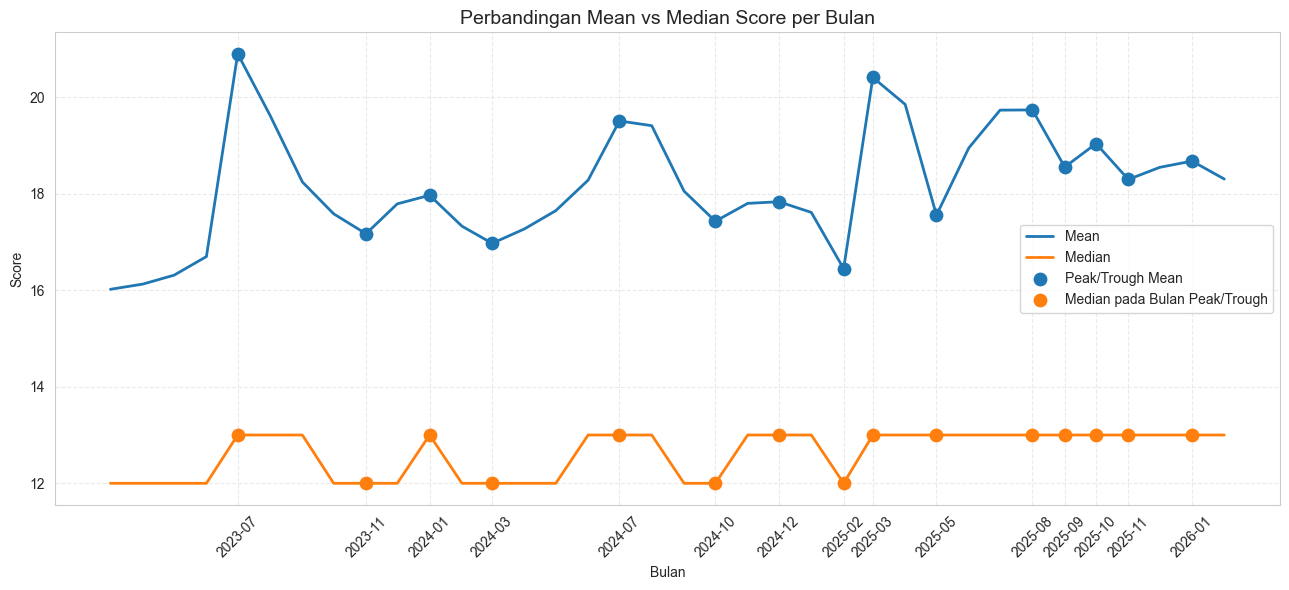

In [8]:
df_ins["INSPECTION DATE"] = pd.to_datetime(df_ins["INSPECTION DATE"], errors="coerce")

trend_df = df_ins[["INSPECTION DATE", "SCORE"]].dropna().copy()
trend_df["month"] = trend_df["INSPECTION DATE"].dt.to_period("M").dt.to_timestamp()

monthly_stats = trend_df.groupby("month")["SCORE"].agg(["mean", "median"]).reset_index()

s = monthly_stats["mean"]
monthly_stats["is_peak"] = (s > s.shift(1)) & (s > s.shift(-1))
monthly_stats["is_trough"] = (s < s.shift(1)) & (s < s.shift(-1))

special_points = monthly_stats[monthly_stats["is_peak"] | monthly_stats["is_trough"]]

plt.figure(figsize=(13, 6))

sns.lineplot(data=monthly_stats, x="month", y="mean", label="Mean", linewidth=2)
sns.lineplot(data=monthly_stats, x="month", y="median", label="Median", linewidth=2)

plt.scatter(
    special_points["month"],
    special_points["mean"],
    s=80,
    zorder=5,
    label="Peak/Trough Mean"
)

plt.scatter(
    special_points["month"],
    special_points["median"],
    s=80,
    zorder=5,
    label="Median pada Bulan Peak/Trough"
)

plt.xticks(
    special_points["month"],
    special_points["month"].dt.strftime("%Y-%m"),
    rotation=45
)

plt.title("Perbandingan Mean vs Median Score per Bulan", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Score")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Penjelasan:**
- Median menunjukkan tipikal score inspeksi sedangkan mean menunjukkan rata-rata keseluruhan
- Perubahan mean kemungkinan karena outlier sehingga lebih sensitif

**Cuisine dengan Score tertinggi**

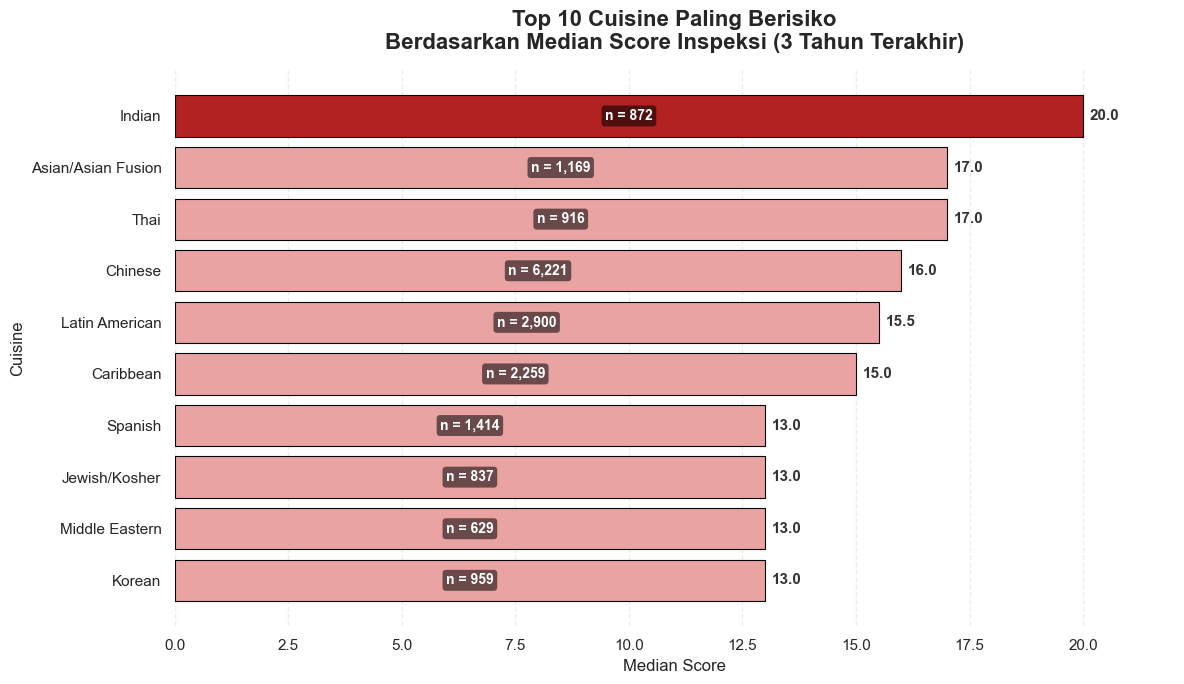

In [9]:
cuisine_stats = (
    df_ins.dropna(subset=["CUISINE_DESCRIPTION", "SCORE"])
    .groupby("CUISINE_DESCRIPTION")
    .agg(
        inspections=("SCORE", "count"),
        mean_score=("SCORE", "mean"),
        median_score=("SCORE", "median")
    )
    .reset_index()
)

min_inspections = 300
cuisine_filtered = cuisine_stats[cuisine_stats["inspections"] >= min_inspections].copy()

top_risky = (
    cuisine_filtered
    .sort_values(["median_score", "mean_score", "inspections"], ascending=False)
    .head(10)
    .sort_values("median_score", ascending=True)
    .reset_index(drop=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#e9a3a3"] * len(top_risky)
colors[-1] = "#b22222"

bars = ax.barh(
    top_risky["CUISINE_DESCRIPTION"],
    top_risky["median_score"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Top 10 Cuisine Paling Berisiko\nBerdasarkan Median Score Inspeksi (3 Tahun Terakhir)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Median Score", fontsize=12)
ax.set_ylabel("Cuisine", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=True)

for bar, score in zip(bars, top_risky["median_score"]):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{score:.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

for bar, n in zip(bars, top_risky["inspections"]):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"n = {n:,}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="black",
            edgecolor="none",
            alpha=0.55
        )
    )

ax.set_xlim(0, top_risky["median_score"].max() + 2)

plt.tight_layout()
plt.show()

**Penjelasan:**
Indian Food memiliki Median Score yang paling tinggi 

**Nilai Mean tiap BORO**

In [10]:
boro_stats = (
    df_ins[df_ins["BORO"].notna() & (df_ins["BORO"] != "Unknown")]
    .groupby("BORO", as_index=False)
    .agg(
        median_score=("SCORE", "median"),
        mean_score=("SCORE", "mean"),
        inspections=("SCORE", "count")
    )
)

boro_stats = boro_stats.sort_values("median_score", ascending=False)
boro_stats

,BORO,median_score,mean_score,inspections
0,Bronx,13.0,17.723636,6600
1,Brooklyn,13.0,18.158726,17798
3,Queens,13.0,19.551193,16223
4,Staten Island,13.0,17.161686,2443
2,Manhattan,12.0,17.384430,25755


In [11]:
geojson_url = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
geojson_path = "boroughs.geojson"

response = requests.get(geojson_url)
response.raise_for_status()

with open(geojson_path, "wb") as f:
    f.write(response.content)

print("GeoJSON berhasil disimpan ke:", geojson_path)

GeoJSON berhasil disimpan ke: boroughs.geojson


In [12]:
boro_gdf = gpd.read_file("boroughs.geojson")
boro_gdf.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330385.03697,1.623853e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,4,Queens,861038.47930,3.049947e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ..."
2,3,Brooklyn,726568.94634,1.959432e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
3,1,Manhattan,358532.95642,6.364422e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [13]:
print(boro_gdf.columns)
print(boro_gdf[["BoroName"]].drop_duplicates())

Index(['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')
        BoroName
0  Staten Island
1         Queens
2       Brooklyn
3      Manhattan
4          Bronx


In [14]:
map_gdf = boro_gdf.merge(boro_stats, left_on="BoroName", right_on="BORO", how="left")
map_gdf[["BoroName", "median_score", "mean_score", "inspections"]]

,BoroName,median_score,mean_score,inspections
0,Staten Island,13.0,17.161686,2443
1,Queens,13.0,19.551193,16223
2,Brooklyn,13.0,18.158726,17798
3,Manhattan,12.0,17.384430,25755
4,Bronx,13.0,17.723636,6600


In [15]:
center = [40.7128, -74.0060]
m = folium.Map(location=center, zoom_start=10, tiles="CartoDB positron")

vmin = float(map_gdf["mean_score"].min())
vmax = float(map_gdf["mean_score"].max())

if vmin == vmax:
    vmax = vmin + 1

colormap = linear.YlOrRd_09.scale(vmin, vmax)
colormap.caption = "Mean Score per BORO (3 Tahun Terakhir)"

def style_function(feature):
    mean_val = feature["properties"].get("mean_score")
    return {
        "fillColor": colormap(mean_val) if mean_val is not None else "#d9d9d9",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.75,
    }

tooltip = folium.GeoJsonTooltip(
    fields=["BoroName", "mean_score", "mean_score", "inspections"],
    aliases=["BORO", "mean Score", "Mean Score", "Jumlah Inspeksi"],
    localize=True,
    sticky=False,
    labels=True,
    style=(
        "background-color: white; color: #333333; font-family: Arial; "
        "font-size: 12px; padding: 8px;"
    ),
)

folium.GeoJson(
    map_gdf,
    name="BORO Score Map",
    style_function=style_function,
    tooltip=tooltip,
).add_to(m)

colormap.add_to(m)

title_html = """
<div style="
    position: fixed;
    top: 10px; left: 50px; width: 380px; z-index: 9999;
    background-color: white; border: 2px solid #444; border-radius: 8px;
    padding: 10px; font-size: 14px; box-shadow: 0 2px 8px rgba(0,0,0,0.2);
">
<b>Peta Mean Score Inspeksi per BORO</b><br>
Periode: 3 tahun terakhir, level inspeksi
</div>
"""

m.save("peta_score_boro_nyc.html")

In [16]:
display(HTML(m._repr_html_()))

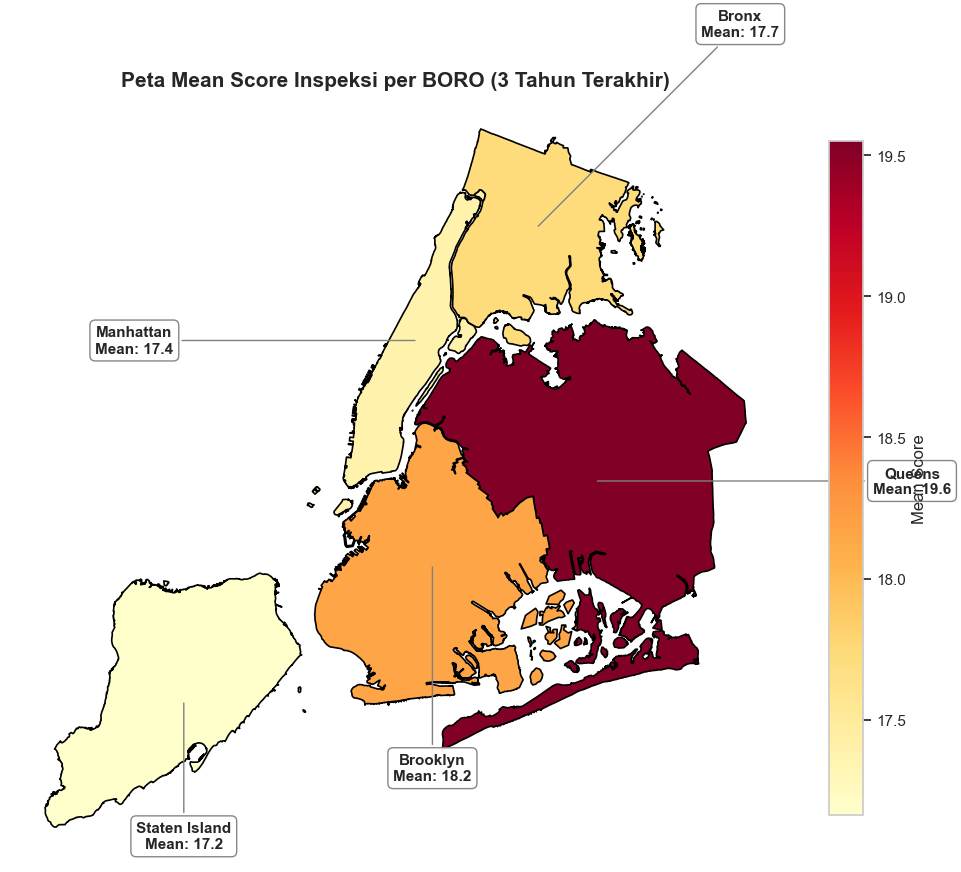

In [17]:

plot_gdf = map_gdf.to_crs(epsg=3857).copy()

label_gdf = plot_gdf.copy()
label_gdf["label_point"] = label_gdf.representative_point()

offsets = {
    "Manhattan": (-25000, 0),
    "Bronx": (18000, 18000),
    "Brooklyn": (0, -18000),
    "Queens": (28000, 0),
    "Staten Island": (0, -12000),
}

fig, ax = plt.subplots(figsize=(10, 10))

plot_gdf.plot(
    column="mean_score",
    cmap="YlOrRd",
    linewidth=1.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Mean Score", "shrink": 0.7}
)

for _, row in label_gdf.iterrows():
    if pd.notna(row["mean_score"]):
        x, y = row["label_point"].x, row["label_point"].y
        dx, dy = offsets.get(row["BoroName"], (0, 0))

        ax.annotate(
            f"{row['BoroName']}\nMean: {row['mean_score']:.1f}",
            xy=(x, y),
            xytext=(x + dx, y + dy),
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.95),
            arrowprops=dict(arrowstyle="-", color="gray", lw=1)
        )

ax.set_title("Peta Mean Score Inspeksi per BORO (3 Tahun Terakhir)", fontsize=15, weight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

**Analisis Rata-Rata Skor pada BORO**
1. Queens adalah boro dengan rata-rata skor tertinggi di antara semua boro.
2. Staten Island memiliki rata-rata skor terendah di antara semua boro.
3. Terdapat boro unknown yang cenderung memiliki rata-rata skor yang cukup tinggi

**Inspeksi dengan Score tertinggi**

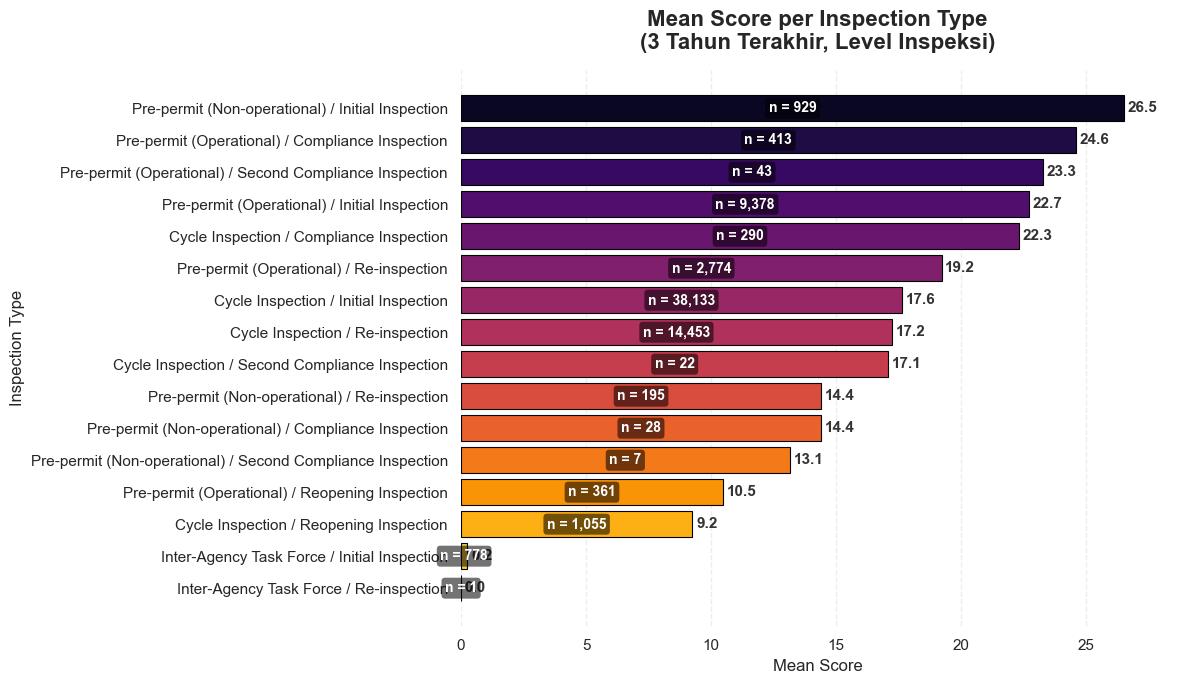

In [18]:
inspection_stats = (
    df_ins.dropna(subset=["INSPECTION TYPE", "SCORE"])
    .groupby("INSPECTION TYPE")
    .agg(
        inspections=("SCORE", "count"),
        mean_score=("SCORE", "mean"),
        median_score=("SCORE", "median")
    )
    .reset_index()
)
inspection_stats = (
    inspection_stats
    .sort_values(["mean_score", "median_score", "inspections"], ascending=True)
    .reset_index(drop=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

colors = sns.color_palette("inferno", n_colors=len(inspection_stats))[::-1]

bars = ax.barh(
    inspection_stats["INSPECTION TYPE"],
    inspection_stats["mean_score"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Mean Score per Inspection Type\n(3 Tahun Terakhir, Level Inspeksi)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Mean Score", fontsize=12)
ax.set_ylabel("Inspection Type", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=True)

for bar, score in zip(bars, inspection_stats["mean_score"]):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{score:.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

for bar, n in zip(bars, inspection_stats["inspections"]):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"n = {n:,}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="black",
            edgecolor="none",
            alpha=0.55
        )
    )

ax.set_xlim(0, inspection_stats["mean_score"].max() + 2)

plt.tight_layout()
plt.show()

**Analisis Skor terhadap Jenis Inspeksi**
1. Intial inspection pada bagian non-operational memiliki skor tertinggi dibandingkan dengan inspeksi lainnya
2. Bagian operational sendiri cenderung memiliki skor yang tinggi jika tipe inspeksinya berupa compliance inspection
3. Cycle inspection cenderung memiliki skor yang lebih rendah
4. Inter-Agency Task Force adalah jenis inspeksi dengan nilai paling rendah, kurang dari 5

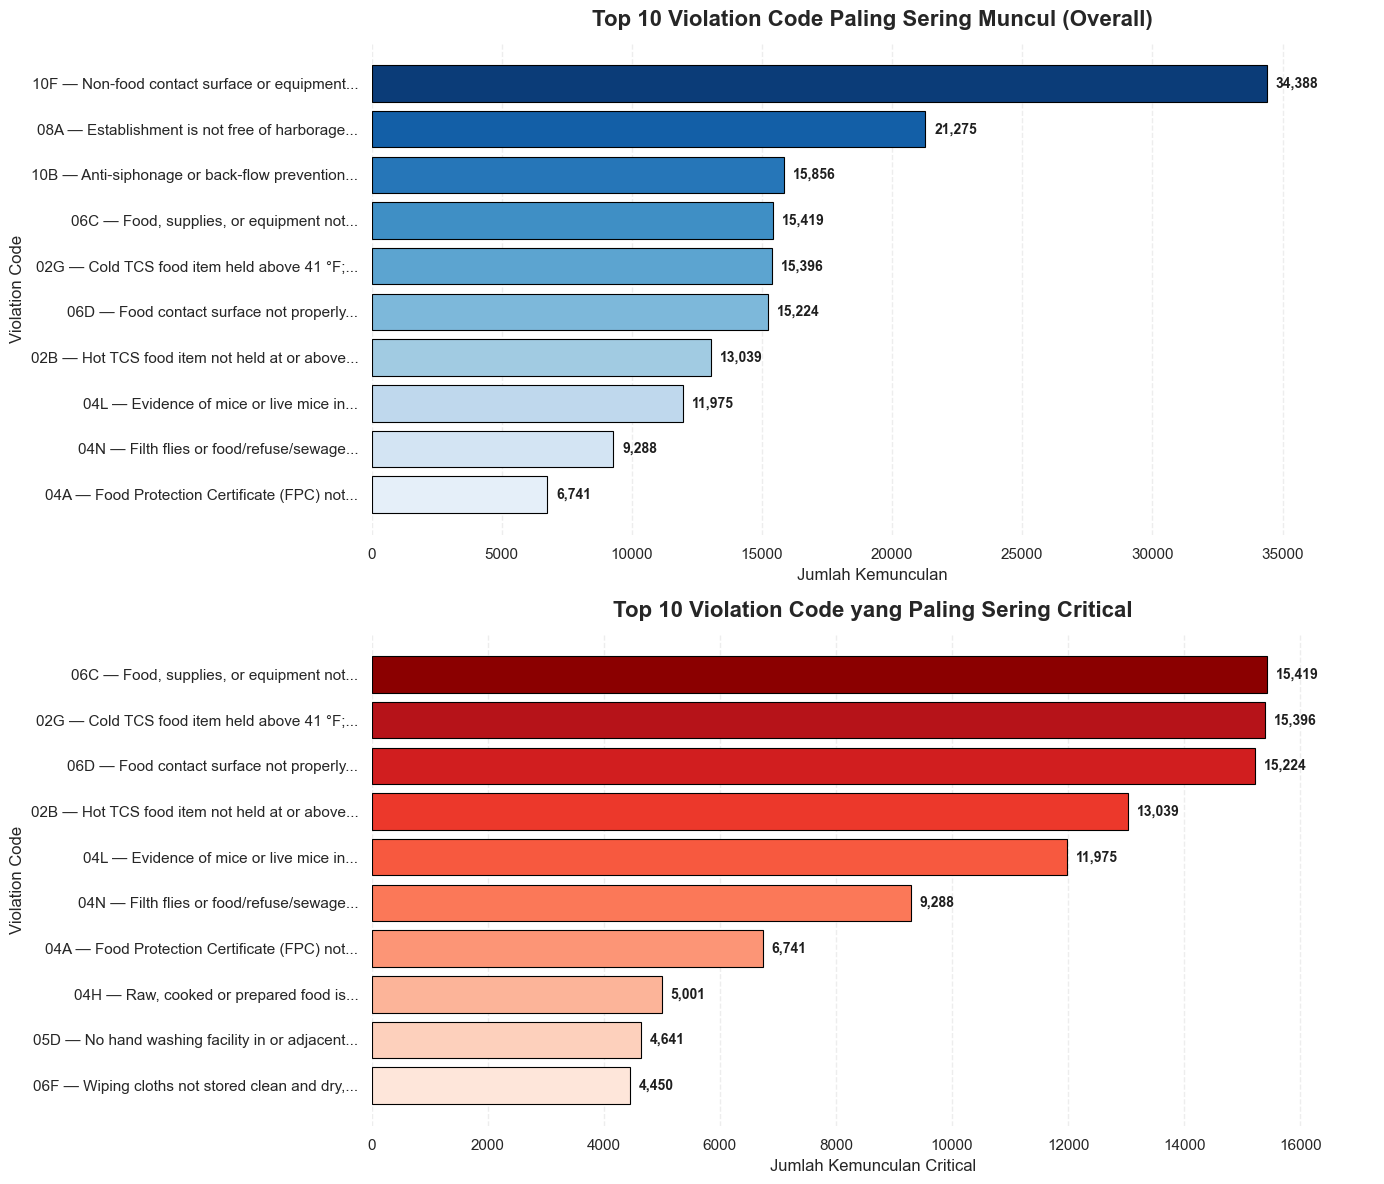

In [19]:
viol_df = df_recent.copy()

viol_df["VIOLATION CODE"] = viol_df["VIOLATION CODE"].astype(str).str.strip()
viol_df["VIOLATION DESCRIPTION"] = viol_df["VIOLATION DESCRIPTION"].astype(str).str.strip()
viol_df["CRITICAL FLAG"] = viol_df["CRITICAL FLAG"].astype(str).str.strip().str.lower()

viol_df = viol_df[
    viol_df["VIOLATION CODE"].notna() &
    (viol_df["VIOLATION CODE"] != "") &
    (viol_df["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = viol_df.drop_duplicates(
    subset=["CAMIS", "INSPECTION DATE", "INSPECTION TYPE", "VIOLATION CODE"]
).copy()

code_desc = (
    viol_level.groupby("VIOLATION CODE")["VIOLATION DESCRIPTION"]
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else x.dropna().iloc[0] if len(x.dropna()) > 0 else "")
    .reset_index()
)

overall_counts = (
    viol_level.groupby("VIOLATION CODE")
    .size()
    .reset_index(name="count_overall")
    .merge(code_desc, on="VIOLATION CODE", how="left")
    .sort_values("count_overall", ascending=False)
    .head(10)
    .sort_values("count_overall", ascending=True)
    .reset_index(drop=True)
)

critical_counts = (
    viol_level[viol_level["CRITICAL FLAG"] == "critical"]
    .groupby("VIOLATION CODE")
    .size()
    .reset_index(name="count_critical")
    .merge(code_desc, on="VIOLATION CODE", how="left")
    .sort_values("count_critical", ascending=False)
    .head(10)
    .sort_values("count_critical", ascending=True)
    .reset_index(drop=True)
)

def make_label(code, desc, width=42):
    short_desc = textwrap.shorten(desc, width=width, placeholder="...")
    return f"{code} — {short_desc}"

overall_counts["label"] = overall_counts.apply(
    lambda row: make_label(row["VIOLATION CODE"], row["VIOLATION DESCRIPTION"]),
    axis=1
)

critical_counts["label"] = critical_counts.apply(
    lambda row: make_label(row["VIOLATION CODE"], row["VIOLATION DESCRIPTION"]),
    axis=1
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

colors_overall = sns.color_palette("Blues", n_colors=len(overall_counts))
colors_overall[-1] = "#0b3c78" 

bars1 = axes[0].barh(
    overall_counts["label"],
    overall_counts["count_overall"],
    color=colors_overall,
    edgecolor="black",
    linewidth=0.8
)

axes[0].set_title(
    "Top 10 Violation Code Paling Sering Muncul (Overall)",
    fontsize=16,
    fontweight="bold",
    pad=12
)
axes[0].set_xlabel("Jumlah Kemunculan", fontsize=12)
axes[0].set_ylabel("Violation Code", fontsize=12)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)
axes[0].grid(axis="y", visible=False)

for bar, val in zip(bars1, overall_counts["count_overall"]):
    axes[0].text(
        bar.get_width() + max(overall_counts["count_overall"]) * 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{val:,}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1f1f1f"
    )

axes[0].set_xlim(0, overall_counts["count_overall"].max() * 1.12)

colors_critical = sns.color_palette("Reds", n_colors=len(critical_counts))
colors_critical[-1] = "#8b0000"  

bars2 = axes[1].barh(
    critical_counts["label"],
    critical_counts["count_critical"],
    color=colors_critical,
    edgecolor="black",
    linewidth=0.8
)

axes[1].set_title(
    "Top 10 Violation Code yang Paling Sering Critical",
    fontsize=16,
    fontweight="bold",
    pad=12
)
axes[1].set_xlabel("Jumlah Kemunculan Critical", fontsize=12)
axes[1].set_ylabel("Violation Code", fontsize=12)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)
axes[1].grid(axis="y", visible=False)

for bar, val in zip(bars2, critical_counts["count_critical"]):
    axes[1].text(
        bar.get_width() + max(critical_counts["count_critical"]) * 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{val:,}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1f1f1f"
    )

axes[1].set_xlim(0, critical_counts["count_critical"].max() * 1.12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Penjelasan:**
- Top overall Violation Code dimiliki oleh 10F sebanyak 34388
- Top critical Violation Code dimiliki oleh 06C sebanyak 15419

**Top 10 Violation Code paling sering muncul dan critical**

In [20]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

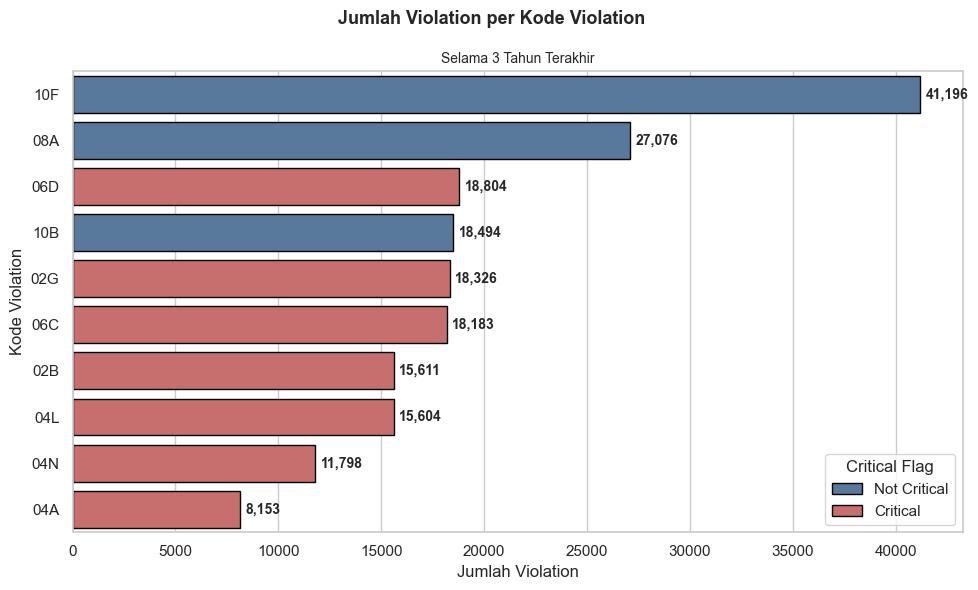

In [21]:
v_count = (
    df.dropna(subset=["VIOLATION CODE", "CRITICAL FLAG"])
      .groupby(["VIOLATION CODE", "CRITICAL FLAG"])
      .size()
      .reset_index(name="count")
      .sort_values(by="count", ascending=False)
      .head(10)
)

palette_map = {
    "Critical": "#D65F5F",
    "Not Critical": "#4C78A8"
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=v_count,
    y="VIOLATION CODE",
    x="count",
    hue="CRITICAL FLAG",
    palette=palette_map,
    edgecolor="black"
)

for container in ax.containers:
    labels = [f"{int(v):,}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=4, fontsize=10, fontweight="bold")

plt.suptitle("Jumlah Violation per Kode Violation", fontsize=13, fontweight="bold")
plt.title("Selama 3 Tahun Terakhir", fontsize=10)
plt.xlabel("Jumlah Violation")
plt.ylabel("Kode Violation")
plt.legend(title="Critical Flag")
plt.tight_layout()
plt.show()

**Analisis Jumlah Violation tiap Kode**
1. Kode violation 10F adalah kode violation yang paling sering terjadi
2. Kode violation 06D adalah kode violation critical yang paling sering terjadi
3. Kebanyakan restoran justru lebih sering memiliki violation non-critical yang sama sedangkan pada critical lebih bervariasi

**Top 10 Violation Code dengan Score tertinggi**

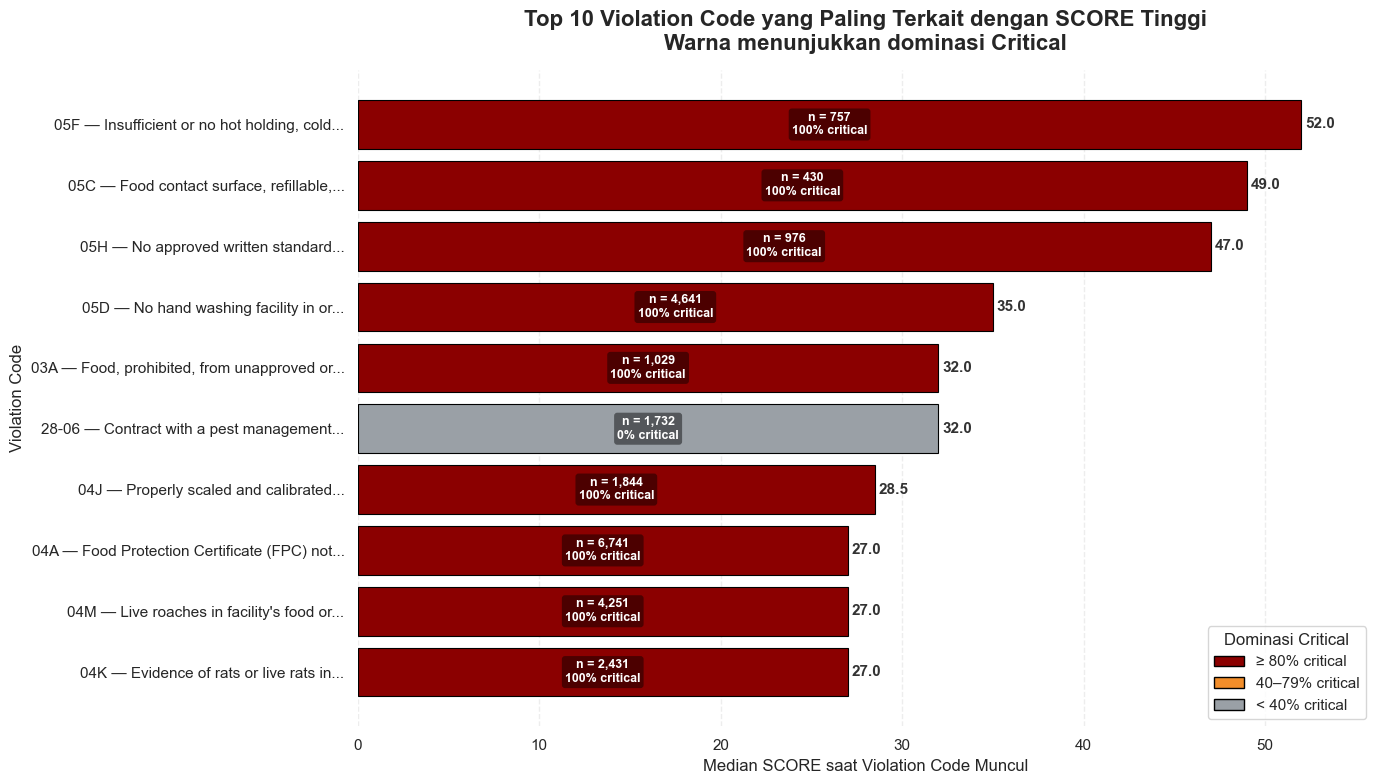

In [22]:
viol_df = df_recent.copy()

viol_df["VIOLATION CODE"] = viol_df["VIOLATION CODE"].astype(str).str.strip()
viol_df["VIOLATION DESCRIPTION"] = viol_df["VIOLATION DESCRIPTION"].astype(str).str.strip()
viol_df["CRITICAL FLAG"] = viol_df["CRITICAL FLAG"].astype(str).str.strip().str.lower()
viol_df["SCORE"] = pd.to_numeric(viol_df["SCORE"], errors="coerce")

viol_df = viol_df[
    viol_df["VIOLATION CODE"].notna() &
    (viol_df["VIOLATION CODE"] != "") &
    (viol_df["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = viol_df.drop_duplicates(
    subset=["CAMIS", "INSPECTION DATE", "INSPECTION TYPE", "VIOLATION CODE"]
).copy()

code_desc = (
    viol_level.groupby("VIOLATION CODE")["VIOLATION DESCRIPTION"]
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty
         else x.dropna().iloc[0] if len(x.dropna()) > 0 else "")
    .reset_index()
)

code_score_stats = (
    viol_level.groupby("VIOLATION CODE")
    .agg(
        inspections_with_code=("SCORE", "count"),
        mean_score_when_present=("SCORE", "mean"),
        median_score_when_present=("SCORE", "median"),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum())
    )
    .reset_index()
    .merge(code_desc, on="VIOLATION CODE", how="left")
)

code_score_stats["critical_pct"] = (
    code_score_stats["critical_count"] / code_score_stats["inspections_with_code"] * 100
)

min_occurrence = 300
code_score_stats = code_score_stats[
    code_score_stats["inspections_with_code"] >= min_occurrence
].copy()

top_codes = (
    code_score_stats
    .sort_values(
        ["median_score_when_present", "mean_score_when_present", "inspections_with_code"],
        ascending=False
    )
    .head(10)
    .sort_values("median_score_when_present", ascending=True)
    .reset_index(drop=True)
)

def make_label(code, desc, width=40):
    short_desc = textwrap.shorten(desc, width=width, placeholder="...")
    return f"{code} — {short_desc}"

top_codes["label"] = top_codes.apply(
    lambda row: make_label(row["VIOLATION CODE"], row["VIOLATION DESCRIPTION"]),
    axis=1
)

def pick_color(pct):
    if pct >= 80:
        return "#8b0000"   
    elif pct >= 40:
        return "#f28e2b"   
    else:
        return "#9aa0a6"   

colors = top_codes["critical_pct"].apply(pick_color).tolist()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top_codes["label"],
    top_codes["median_score_when_present"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Top 10 Violation Code yang Paling Terkait dengan SCORE Tinggi\n"
    "Warna menunjukkan dominasi Critical",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Median SCORE saat Violation Code Muncul", fontsize=12)
ax.set_ylabel("Violation Code", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=True)

for bar, score in zip(bars, top_codes["median_score_when_present"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

for bar, n, pct in zip(bars, top_codes["inspections_with_code"], top_codes["critical_pct"]):
    ax.text(
        bar.get_width() * 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"n = {n:,}\n{pct:.0f}% critical",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="black",
            edgecolor="none",
            alpha=0.45
        )
    )

ax.set_xlim(0, top_codes["median_score_when_present"].max() + 4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#8b0000", edgecolor="black", label="≥ 80% critical"),
    Patch(facecolor="#f28e2b", edgecolor="black", label="40–79% critical"),
    Patch(facecolor="#9aa0a6", edgecolor="black", label="< 40% critical"),
]
ax.legend(handles=legend_elements, title="Dominasi Critical", loc="lower right")

plt.tight_layout()
plt.show()

**Penjelasan:** 
- 9/10 Code yang ada merupakan Critical violation code
- 05F merupakan code dengan nilai median score tertinggi
- Critical code sangat berpengaruh terhadap score yang tinggi 

**Korelasi Critical Code dengan Score tinggi**

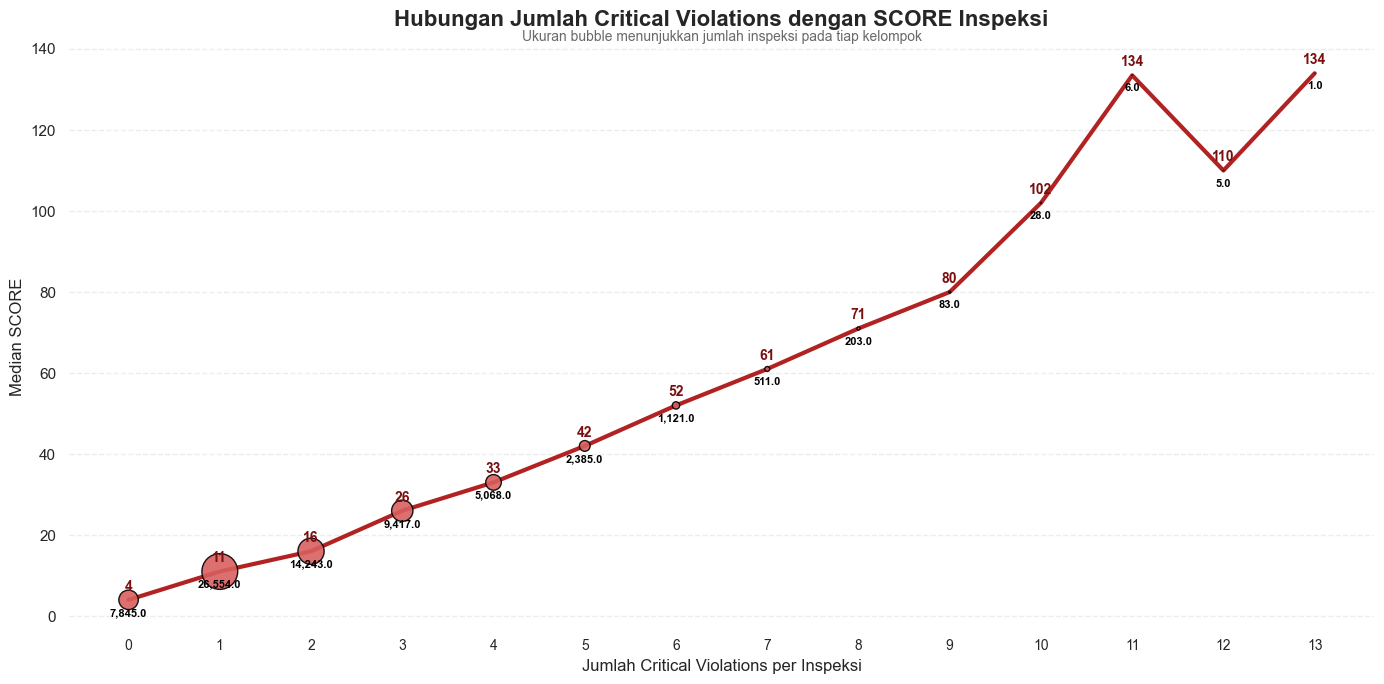

In [23]:
viol_df = df_recent.copy()

viol_df["CRITICAL FLAG"] = viol_df["CRITICAL FLAG"].astype(str).str.strip().str.lower()
viol_df["VIOLATION CODE"] = viol_df["VIOLATION CODE"].astype(str).str.strip()
viol_df["SCORE"] = pd.to_numeric(viol_df["SCORE"], errors="coerce")

viol_df = viol_df[
    viol_df["VIOLATION CODE"].notna() &
    (viol_df["VIOLATION CODE"] != "") &
    (viol_df["VIOLATION CODE"].str.lower() != "nan")
].copy()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

viol_level = viol_df.drop_duplicates(
    subset=inspection_key + ["VIOLATION CODE"]
).copy()

inspection_summary = (
    viol_level.groupby(inspection_key)
    .agg(
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        score=("SCORE", "first")
    )
    .reset_index()
)

inspection_summary = inspection_summary.dropna(subset=["score"]).copy()

summary_plot = (
    inspection_summary.groupby("critical_count", as_index=False)
    .agg(
        median_score=("score", "median"),
        mean_score=("score", "mean"),
        inspections=("score", "count")
    )
    .sort_values("critical_count")
    .reset_index(drop=True)
)

summary_plot["x"] = range(len(summary_plot))

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    summary_plot["x"],
    summary_plot["median_score"],
    color="#b22222",
    linewidth=3,
    zorder=2
)

bubble_sizes = summary_plot["inspections"] / 40
ax.scatter(
    summary_plot["x"],
    summary_plot["median_score"],
    s=bubble_sizes,
    color="#d95f5f",
    edgecolor="black",
    linewidth=1,
    alpha=0.9,
    zorder=3
)

for _, row in summary_plot.iterrows():
    ax.text(
        row["x"],
        row["median_score"] + 1.5,
        f"{row['median_score']:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#7a0f0f"
    )

for _, row in summary_plot.iterrows():
    ax.text(
        row["x"],
        row["median_score"] - 2,
        f"{row['inspections']:,}",
        ha="center",
        va="top",
        fontsize=8,
        fontweight="bold",
        color="black"
    )

ax.set_title(
    "Hubungan Jumlah Critical Violations dengan SCORE Inspeksi",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Jumlah Critical Violations per Inspeksi", fontsize=12)
ax.set_ylabel("Median SCORE", fontsize=12)

ax.set_xticks(summary_plot["x"])
ax.set_xticklabels(summary_plot["critical_count"], fontsize=10, rotation=0)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
sns.despine(left=True, bottom=True)

ax.text(
    0.5, 1.01,
    "Ukuran bubble menunjukkan jumlah inspeksi pada tiap kelompok",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout()
plt.show()

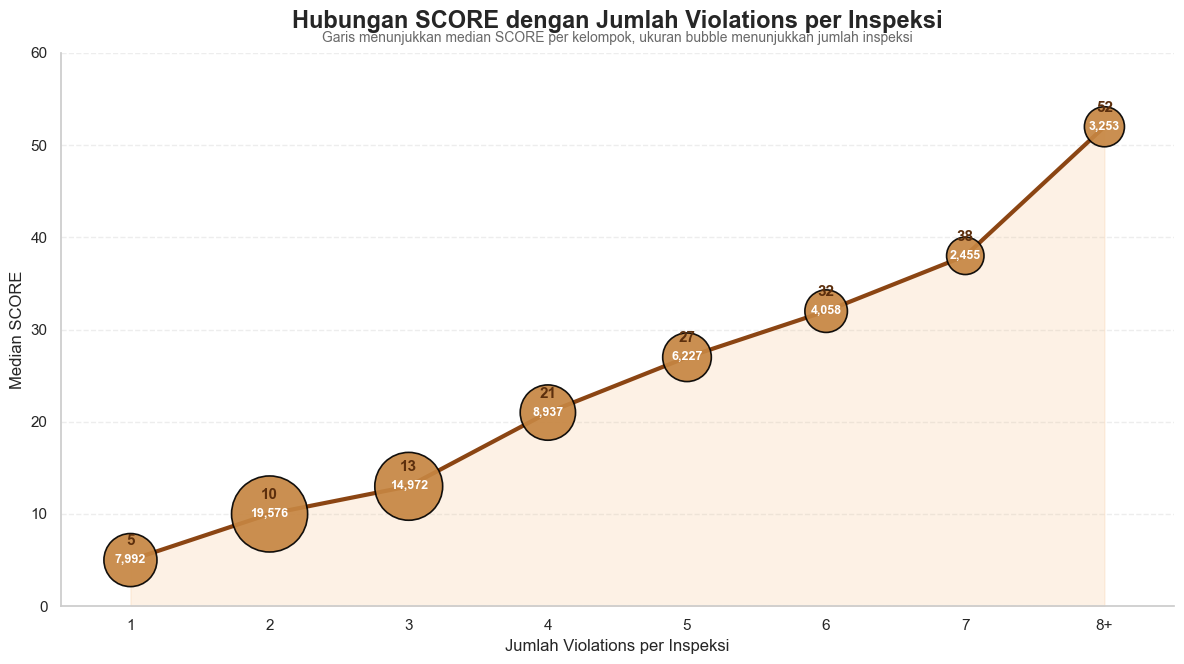

In [24]:
data = df_recent.copy()

data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()
data["SCORE"] = pd.to_numeric(data["SCORE"], errors="coerce")

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

inspection_summary = (
    viol_level.groupby(inspection_key)
    .agg(
        score=("SCORE", "first"),
        violation_count=("VIOLATION CODE", "count")
    )
    .reset_index()
)

inspection_summary = inspection_summary.dropna(subset=["score"]).copy()

def bucket_violation(x):
    return "8+" if x >= 8 else str(int(x))

inspection_summary["violation_bucket"] = inspection_summary["violation_count"].apply(bucket_violation)

bucket_order = ["1", "2", "3", "4", "5", "6", "7", "8+"]

trend_df = (
    inspection_summary.groupby("violation_bucket", as_index=False)
    .agg(
        median_score=("score", "median"),
        inspections=("score", "count")
    )
)

trend_df["violation_bucket"] = pd.Categorical(
    trend_df["violation_bucket"],
    categories=bucket_order,
    ordered=True
)
trend_df = trend_df.sort_values("violation_bucket").reset_index(drop=True)
trend_df["x"] = np.arange(len(trend_df))

trend_df["bubble_size"] = 400 + (trend_df["inspections"] / trend_df["inspections"].max()) * 2600

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.fill_between(
    trend_df["x"],
    trend_df["median_score"],
    color="#f6c08b",
    alpha=0.22,
    zorder=1
)

ax.plot(
    trend_df["x"],
    trend_df["median_score"],
    color="#8b4513",
    linewidth=3,
    zorder=2
)

ax.scatter(
    trend_df["x"],
    trend_df["median_score"],
    s=trend_df["bubble_size"],
    color="#c68642",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.92,
    zorder=3
)

for _, row in trend_df.iterrows():
    ax.text(
        row["x"],
        row["median_score"] + 1.3,
        f"{row['median_score']:.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#5c2f0d"
    )
    
for _, row in trend_df.iterrows():
    ax.text(
        row["x"],
        row["median_score"],
        f"{row['inspections']:,}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

ax.set_title(
    "Hubungan SCORE dengan Jumlah Violations per Inspeksi",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5, 1.02,
    "Garis menunjukkan median SCORE per kelompok, ukuran bubble menunjukkan jumlah inspeksi",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="dimgray"
)

ax.set_xlabel("Jumlah Violations per Inspeksi", fontsize=12)
ax.set_ylabel("Median SCORE", fontsize=12)

ax.set_xticks(trend_df["x"])
ax.set_xticklabels(trend_df["violation_bucket"], fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

ax.set_ylim(0, trend_df["median_score"].max() + 8)
ax.set_xlim(-0.5, len(trend_df) - 0.5)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

**Analisis Score terhadap Jumlah Critical Violation**
1. Hubungan cenderung linear seiring bertambahnya jumlah critical violation, meningkat sekitar 10-15 poin tiap critical violation
2. Terdapat lonjakan drastis pada jumlah critical violation 11 ke 12, meningkat sekitar 30 poin
3. Setelah lonjakan, terjadi penurunan pada jumlah critical violation 12 ke 13

**Restoran sebagai repeat offender pada tipe violation yang sama**

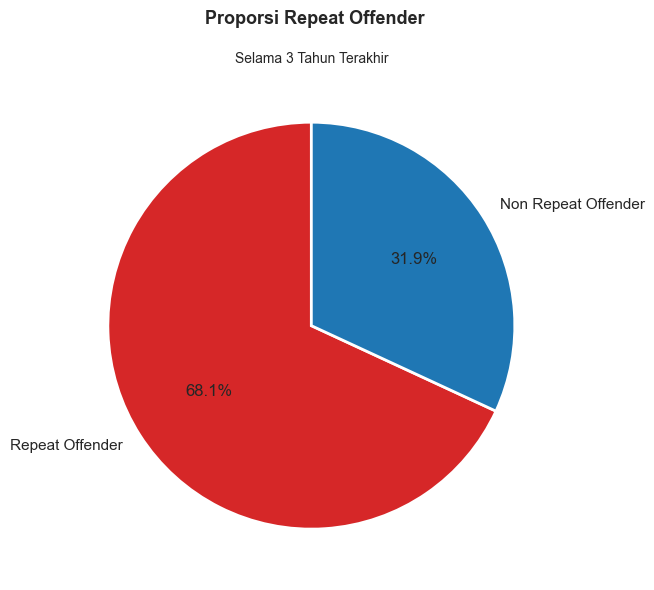

In [25]:
total_camis = df_ins['CAMIS'].nunique()

repeat_offenders = (df_ins[df_ins['has_critical'] == True].groupby('CAMIS')['INSPECTION DATE'].nunique().reset_index(name='critical_count'))

jumlah_repeat = repeat_offenders[repeat_offenders['critical_count'] > 1]['CAMIS'].nunique()
jumlah_non_repeat = total_camis - jumlah_repeat

labels = ['Repeat Offender', 'Non Repeat Offender']
values = [jumlah_repeat, jumlah_non_repeat]

plt.figure(figsize=(8, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#d62728', '#1f77b4'],startangle=90,wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.suptitle('Proporsi Repeat Offender', fontsize=13, fontweight='bold')
plt.title('Selama 3 Tahun Terakhir', fontsize=10)
plt.tight_layout()
plt.show()

**Analisis Proporsi Repeat Offender**
1. Lebih dari 68% dari total restoran yang ada merupakan restaurant repeat offender
2. Tingginya jumlah repeat offender menandakan mayoritas restoran tidak melakukan perbaikan setelah adanya inspeksi

**Restoran sebagai repeat offender pada tipe violation yang sama**

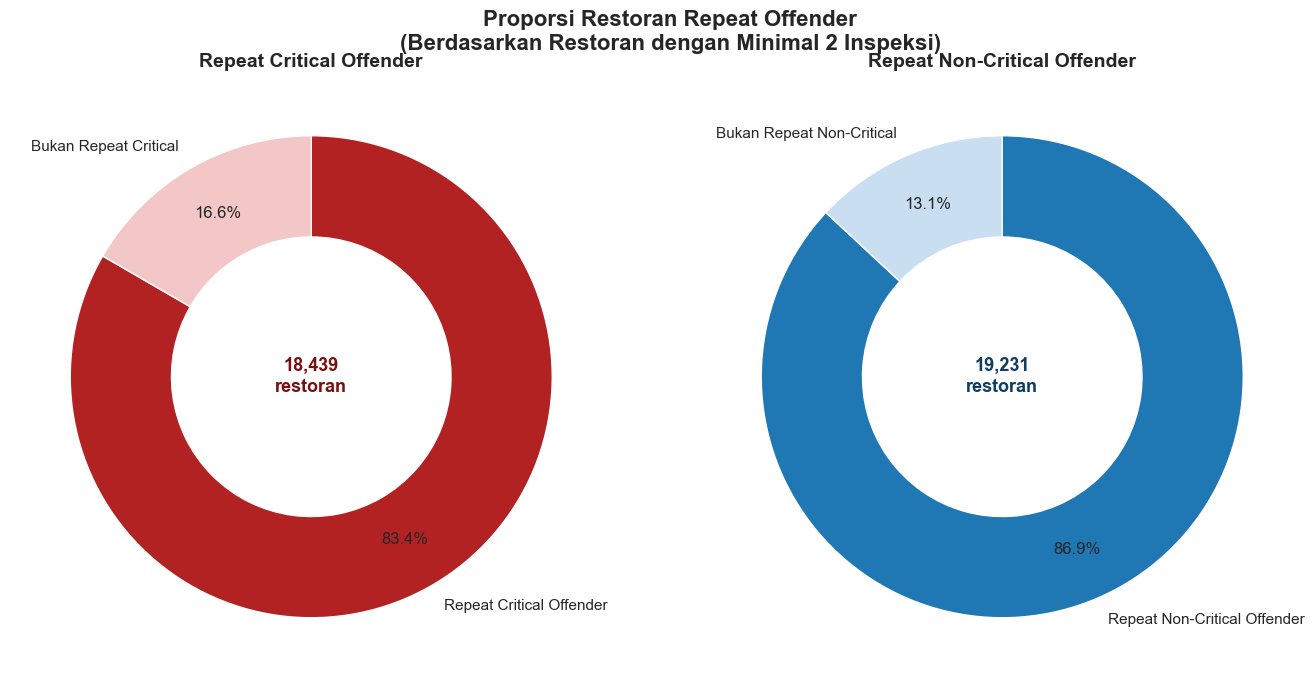

In [26]:
data = df_recent.copy()

data["CRITICAL FLAG"] = data["CRITICAL FLAG"].astype(str).str.strip().str.lower()
data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

inspection_summary = (
    viol_level.groupby(inspection_key)
    .agg(
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),
        has_noncritical=("CRITICAL FLAG", lambda x: (x != "critical").any())
    )
    .reset_index()
)

restaurant_summary = (
    inspection_summary.groupby("CAMIS")
    .agg(
        total_inspections=("INSPECTION DATE", "count"),
        critical_inspections=("has_critical", "sum"),
        noncritical_inspections=("has_noncritical", "sum")
    )
    .reset_index()
)

restaurant_summary = restaurant_summary[
    restaurant_summary["total_inspections"] >= 2
].copy()

restaurant_summary["repeat_critical_offender"] = restaurant_summary["critical_inspections"] >= 2
restaurant_summary["repeat_noncritical_offender"] = restaurant_summary["noncritical_inspections"] >= 2

critical_counts = restaurant_summary["repeat_critical_offender"].value_counts()
noncritical_counts = restaurant_summary["repeat_noncritical_offender"].value_counts()

critical_repeat = critical_counts.get(True, 0)
critical_nonrepeat = critical_counts.get(False, 0)

noncritical_repeat = noncritical_counts.get(True, 0)
noncritical_nonrepeat = noncritical_counts.get(False, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Proporsi Restoran Repeat Offender\n(Berdasarkan Restoran dengan Minimal 2 Inspeksi)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

sizes1 = [critical_repeat, critical_nonrepeat]
labels1 = ["Repeat Critical Offender", "Bukan Repeat Critical"]
colors1 = ["#b22222", "#f3c7c7"]

wedges1, texts1, autotexts1 = axes[0].pie(
    sizes1,
    labels=labels1,
    colors=colors1,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

axes[0].set_title("Repeat Critical Offender", fontsize=14, fontweight="bold")
axes[0].text(
    0, 0,
    f"{critical_repeat:,}\nrestoran",
    ha="center", va="center",
    fontsize=13, fontweight="bold", color="#7a0f0f"
)

sizes2 = [noncritical_repeat, noncritical_nonrepeat]
labels2 = ["Repeat Non-Critical Offender", "Bukan Repeat Non-Critical"]
colors2 = ["#1f77b4", "#c9def1"]

wedges2, texts2, autotexts2 = axes[1].pie(
    sizes2,
    labels=labels2,
    colors=colors2,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

axes[1].set_title("Repeat Non-Critical Offender", fontsize=14, fontweight="bold")
axes[1].text(
    0, 0,
    f"{noncritical_repeat:,}\nrestoran",
    ha="center", va="center",
    fontsize=13, fontweight="bold", color="#0f3d63"
)

plt.tight_layout()
plt.show()

**Penjelasan:**
- 83,4% Restoran mengulangi critical violation 
- 86,9% Restoran mengulangi Non-Critical Violation

**Restoran sebagai repeat offender pada violation code yang sama**

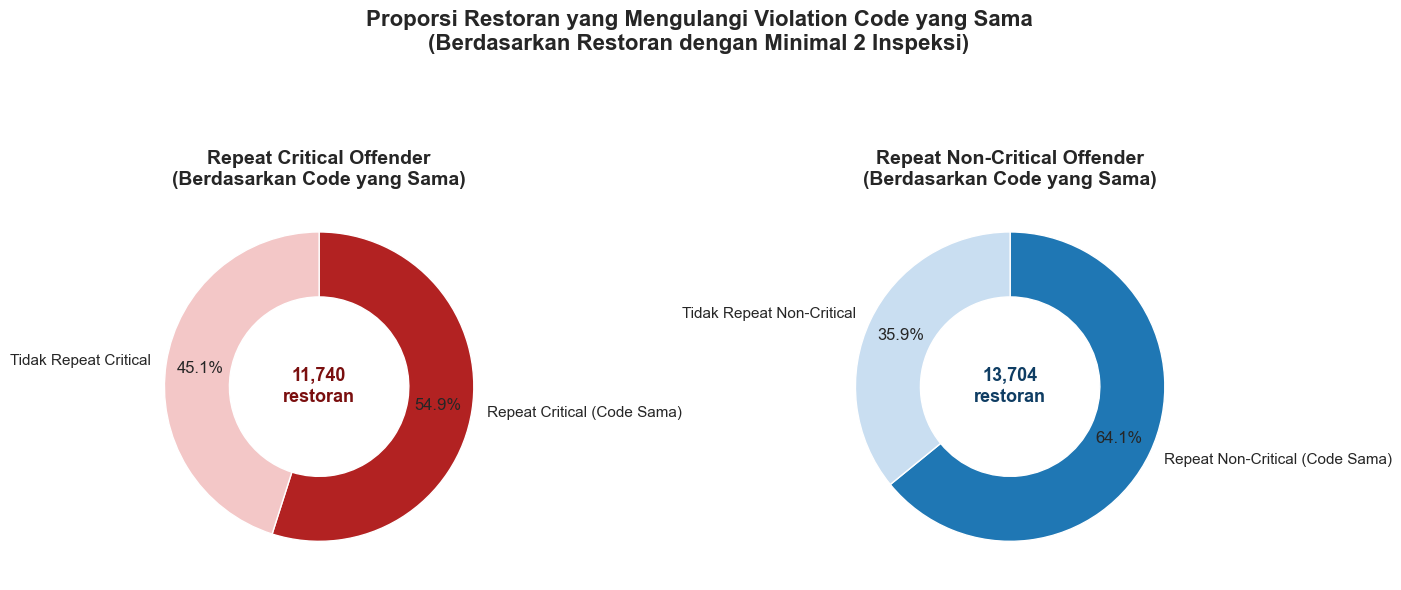

In [27]:
data = df_recent.copy()

data["CRITICAL FLAG"] = data["CRITICAL FLAG"].astype(str).str.strip().str.lower()
data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

code_repeat = (
    viol_level.groupby(["CAMIS", "VIOLATION CODE", "CRITICAL FLAG"])
    .agg(
        inspection_count=("INSPECTION DATE", "nunique")
    )
    .reset_index()
)

code_repeat["is_repeat_code"] = code_repeat["inspection_count"] >= 2

restaurant_inspections = (
    viol_level.groupby("CAMIS")
    .agg(total_inspections=("INSPECTION DATE", "nunique"))
    .reset_index()
)

repeat_critical_restaurants = (
    code_repeat[
        (code_repeat["CRITICAL FLAG"] == "critical") &
        (code_repeat["is_repeat_code"])
    ]["CAMIS"]
    .drop_duplicates()
)

repeat_noncritical_restaurants = (
    code_repeat[
        (code_repeat["CRITICAL FLAG"] != "critical") &
        (code_repeat["is_repeat_code"])
    ]["CAMIS"]
    .drop_duplicates()
)

restaurant_summary = restaurant_inspections.copy()

restaurant_summary = restaurant_summary[
    restaurant_summary["total_inspections"] >= 2
].copy()

restaurant_summary["repeat_critical_same_code"] = restaurant_summary["CAMIS"].isin(repeat_critical_restaurants)
restaurant_summary["repeat_noncritical_same_code"] = restaurant_summary["CAMIS"].isin(repeat_noncritical_restaurants)

critical_repeat = restaurant_summary["repeat_critical_same_code"].sum()
critical_nonrepeat = len(restaurant_summary) - critical_repeat

noncritical_repeat = restaurant_summary["repeat_noncritical_same_code"].sum()
noncritical_nonrepeat = len(restaurant_summary) - noncritical_repeat

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Proporsi Restoran yang Mengulangi Violation Code yang Sama\n"
    "(Berdasarkan Restoran dengan Minimal 2 Inspeksi)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

sizes1 = [critical_repeat, critical_nonrepeat]
labels1 = ["Repeat Critical (Code Sama)", "Tidak Repeat Critical"]
colors1 = ["#b22222", "#f3c7c7"]

axes[0].pie(
    sizes1,
    labels=labels1,
    colors=colors1,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

axes[0].set_title("Repeat Critical Offender\n(Berdasarkan Code yang Sama)", fontsize=14, fontweight="bold")
axes[0].text(
    0, 0,
    f"{critical_repeat:,}\nrestoran",
    ha="center", va="center",
    fontsize=13, fontweight="bold", color="#7a0f0f"
)

sizes2 = [noncritical_repeat, noncritical_nonrepeat]
labels2 = ["Repeat Non-Critical (Code Sama)", "Tidak Repeat Non-Critical"]
colors2 = ["#1f77b4", "#c9def1"]

axes[1].pie(
    sizes2,
    labels=labels2,
    colors=colors2,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

axes[1].set_title("Repeat Non-Critical Offender\n(Berdasarkan Code yang Sama)", fontsize=14, fontweight="bold")
axes[1].text(
    0, 0,
    f"{noncritical_repeat:,}\nrestoran",
    ha="center", va="center",
    fontsize=13, fontweight="bold", color="#0f3d63"
)

plt.tight_layout()
plt.show()

**Penjelasan:**
- 54,9% Restoran mengulangi Critical Violation yang sama persis
- 64,1% Restoran mengulangi Non-Critical Violation yang sama persis

**Top Violation Code yang sering diulang**

In [28]:
data = df_recent.copy()

data["CRITICAL FLAG"] = data["CRITICAL FLAG"].astype(str).str.strip().str.lower()
data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()
data["VIOLATION DESCRIPTION"] = data["VIOLATION DESCRIPTION"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

code_repeat = (
    viol_level.groupby(["CAMIS", "VIOLATION CODE", "CRITICAL FLAG"])
    .agg(inspection_count=("INSPECTION DATE", "nunique"))
    .reset_index()
)

code_repeat["is_repeat_code"] = code_repeat["inspection_count"] >= 2

code_desc = (
    viol_level.groupby("VIOLATION CODE")["VIOLATION DESCRIPTION"]
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty
         else x.dropna().iloc[0] if len(x.dropna()) > 0 else "")
    .reset_index()
)

restaurants_with_code = (
    code_repeat.groupby(["VIOLATION CODE", "CRITICAL FLAG"])
    .agg(restaurants_with_code=("CAMIS", "nunique"))
    .reset_index()
)

repeated_restaurants = (
    code_repeat[code_repeat["is_repeat_code"]]
    .groupby(["VIOLATION CODE", "CRITICAL FLAG"])
    .agg(repeated_restaurants=("CAMIS", "nunique"))
    .reset_index()
)

top_repeat_codes = (
    restaurants_with_code
    .merge(repeated_restaurants, on=["VIOLATION CODE", "CRITICAL FLAG"], how="left")
    .merge(code_desc, on="VIOLATION CODE", how="left")
)

top_repeat_codes["repeated_restaurants"] = top_repeat_codes["repeated_restaurants"].fillna(0)
top_repeat_codes["repeat_rate_pct"] = (
    top_repeat_codes["repeated_restaurants"] / top_repeat_codes["restaurants_with_code"] * 100
)

top_repeat_codes = top_repeat_codes.sort_values(
    ["repeat_rate_pct", "repeated_restaurants", "restaurants_with_code"],
    ascending=False
)

top_repeat_codes.head(15)

,VIOLATION CODE,CRITICAL FLAG,restaurants_with_code,repeated_restaurants,VIOLATION DESCRIPTION,repeat_rate_pct
63,10F,not critical,20394,9779.0,Non-food contact surface or equipment made of ...,47.950378
49,08A,not critical,12887,5353.0,Establishment is not free of harborage or cond...,41.537984
26,04L,critical,7755,2822.0,Evidence of mice or live mice in establishment...,36.389426
1,02B,critical,8940,2858.0,Hot TCS food item not held at or above 140 °F.,31.968680
5,02G,critical,10830,3330.0,Cold TCS food item held above 41 °F; smoked or...,30.747922
42,06D,critical,11164,3184.0,"Food contact surface not properly washed, rins...",28.520244
41,06C,critical,11461,3042.0,"Food, supplies, or equipment not protected fro...",26.542187
16,04A,critical,4906,1268.0,Food Protection Certificate (FPC) not held by ...,25.845903
59,10B,not critical,11972,3087.0,Anti-siphonage or back-flow prevention device ...,25.785165
27,04M,critical,3181,793.0,Live roaches in facility's food or non-food area.,24.929268


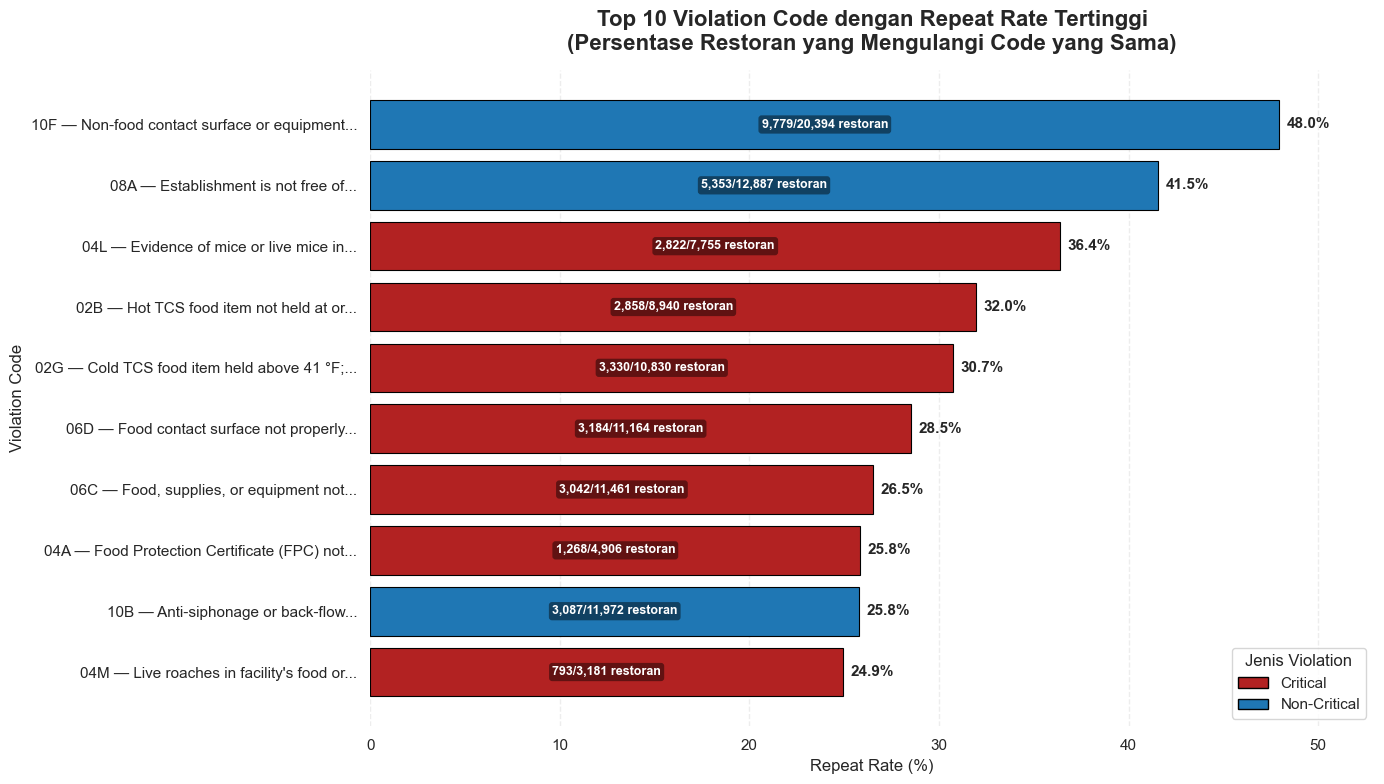

In [29]:
plot_df = top_repeat_codes.head(10).copy()
plot_df = plot_df.sort_values("repeat_rate_pct", ascending=True)

def make_label(code, desc, width=40):
    short_desc = textwrap.shorten(desc, width=width, placeholder="...")
    return f"{code} — {short_desc}"

plot_df["label"] = plot_df.apply(
    lambda row: make_label(row["VIOLATION CODE"], row["VIOLATION DESCRIPTION"]),
    axis=1
)

def pick_color(flag):
    return "#b22222" if flag == "critical" else "#1f77b4"

colors = plot_df["CRITICAL FLAG"].apply(pick_color).tolist()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    plot_df["label"],
    plot_df["repeat_rate_pct"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Top 10 Violation Code dengan Repeat Rate Tertinggi\n"
    "(Persentase Restoran yang Mengulangi Code yang Sama)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Repeat Rate (%)", fontsize=12)
ax.set_ylabel("Violation Code", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=True)

for bar, pct in zip(bars, plot_df["repeat_rate_pct"]):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

for bar, rep, total in zip(
    bars,
    plot_df["repeated_restaurants"],
    plot_df["restaurants_with_code"]
):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(rep):,}/{int(total):,} restoran",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="black",
            edgecolor="none",
            alpha=0.45
        )
    )

ax.set_xlim(0, plot_df["repeat_rate_pct"].max() + 5)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#b22222", edgecolor="black", label="Critical"),
    Patch(facecolor="#1f77b4", edgecolor="black", label="Non-Critical"),
]
ax.legend(handles=legend_elements, title="Jenis Violation", loc="lower right")

plt.tight_layout()
plt.show()

**Cuisine dengan tingkat repeat offender terbanyak**

In [30]:
data = df_recent.copy()

data["CRITICAL FLAG"] = data["CRITICAL FLAG"].astype(str).str.strip().str.lower()
data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()
data["CUISINE DESCRIPTION"] = data["CUISINE DESCRIPTION"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

cuisine_map = (
    viol_level[
        viol_level["CUISINE DESCRIPTION"].notna() &
        (viol_level["CUISINE DESCRIPTION"] != "") &
        (viol_level["CUISINE DESCRIPTION"].str.lower() != "nan")
    ]
    .groupby("CAMIS")["CUISINE DESCRIPTION"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
    .rename(columns={"CUISINE DESCRIPTION": "CUISINE_MAIN"})
)

inspection_summary = (
    viol_level.groupby(inspection_key)
    .agg(
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),
        has_noncritical=("CRITICAL FLAG", lambda x: (x != "critical").any())
    )
    .reset_index()
)

restaurant_summary = (
    inspection_summary.groupby("CAMIS")
    .agg(
        total_inspections=("INSPECTION DATE", "count"),
        critical_inspections=("has_critical", "sum"),
        noncritical_inspections=("has_noncritical", "sum")
    )
    .reset_index()
)

restaurant_summary = restaurant_summary[
    restaurant_summary["total_inspections"] >= 2
].copy()

restaurant_summary["repeat_critical_offender"] = (
    restaurant_summary["critical_inspections"] >= 2
)
restaurant_summary["repeat_noncritical_offender"] = (
    restaurant_summary["noncritical_inspections"] >= 2
)

restaurant_summary = restaurant_summary.merge(
    cuisine_map,
    on="CAMIS",
    how="left"
)

restaurant_summary = restaurant_summary[
    restaurant_summary["CUISINE_MAIN"].notna()
].copy()

cuisine_repeat = (
    restaurant_summary.groupby("CUISINE_MAIN")
    .agg(
        eligible_restaurants=("CAMIS", "nunique"),
        repeat_critical_count=("repeat_critical_offender", "sum"),
        repeat_noncritical_count=("repeat_noncritical_offender", "sum")
    )
    .reset_index()
)

cuisine_repeat["repeat_critical_pct"] = (
    cuisine_repeat["repeat_critical_count"] / cuisine_repeat["eligible_restaurants"] * 100
)
cuisine_repeat["repeat_noncritical_pct"] = (
    cuisine_repeat["repeat_noncritical_count"] / cuisine_repeat["eligible_restaurants"] * 100
)

min_restaurants = 50
cuisine_repeat = cuisine_repeat[
    cuisine_repeat["eligible_restaurants"] >= min_restaurants
].copy()

top_cuisine = (
    cuisine_repeat
    .sort_values(
        ["repeat_critical_pct", "repeat_noncritical_pct", "eligible_restaurants"],
        ascending=False
    )
    .head(10)
    .sort_values("repeat_critical_pct", ascending=True)
    .reset_index(drop=True)
)

top_cuisine

,CUISINE_MAIN,eligible_restaurants,repeat_critical_count,repeat_noncritical_count,repeat_critical_pct,repeat_noncritical_pct
0,Korean,317,281,265,88.643533,83.596215
1,Spanish,444,394,396,88.738739,89.189189
2,Thai,289,257,249,88.927336,86.159170
3,Chinese,1956,1744,1689,89.161554,86.349693
4,African,80,73,71,91.250000,88.750000
5,Bagels/Pretzels,196,180,179,91.836735,91.326531
6,Peruvian,81,75,75,92.592593,92.592593
7,Bangladeshi,71,66,65,92.957746,91.549296
8,Southeast Asian,86,80,75,93.023256,87.209302
9,Indian,262,244,238,93.129771,90.839695


In [31]:
plot_df = top_cuisine.melt(
    id_vars=["CUISINE_MAIN", "eligible_restaurants"],
    value_vars=["repeat_critical_pct", "repeat_noncritical_pct"],
    var_name="repeat_type",
    value_name="repeat_pct"
)

plot_df["repeat_type"] = plot_df["repeat_type"].map({
    "repeat_critical_pct": "Repeat Critical",
    "repeat_noncritical_pct": "Repeat Non-Critical"
})

plot_df["CUISINE_MAIN"] = pd.Categorical(
    plot_df["CUISINE_MAIN"],
    categories=top_cuisine["CUISINE_MAIN"],
    ordered=True
)

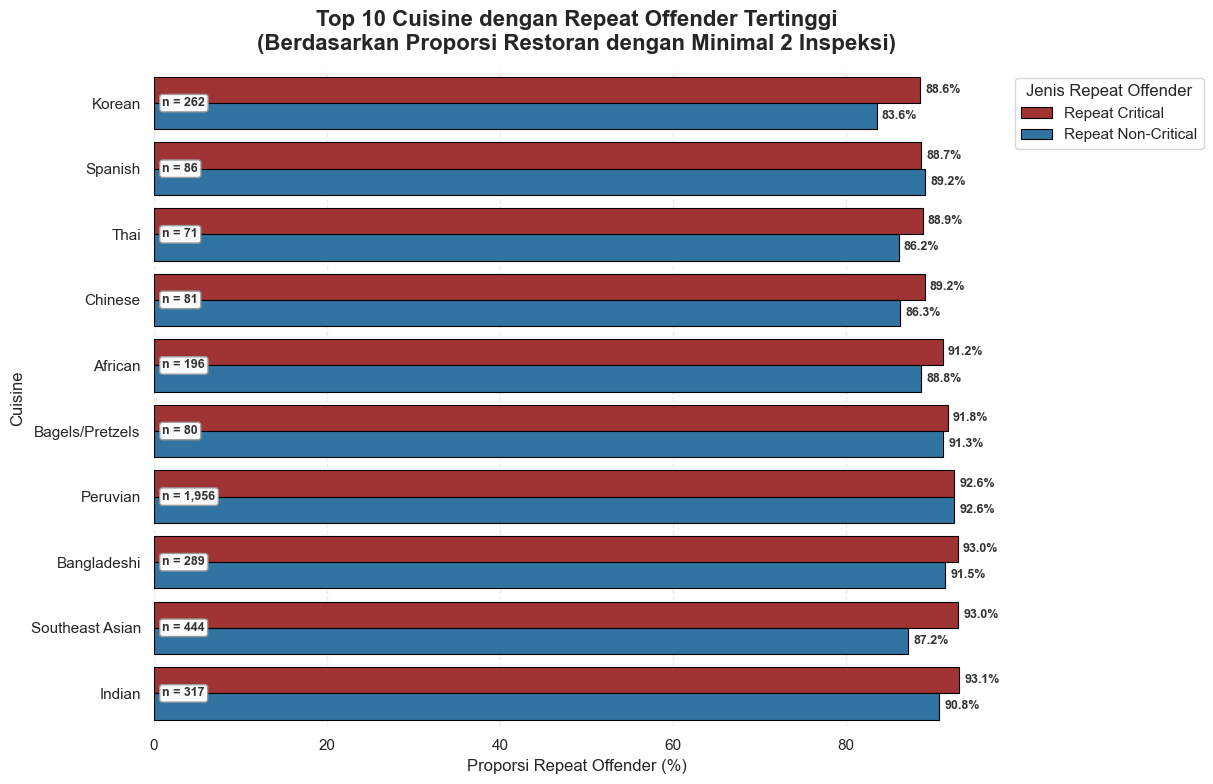

In [32]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

palette = {
    "Repeat Critical": "#b22222",
    "Repeat Non-Critical": "#1f77b4"
}

sns.barplot(
    data=plot_df,
    x="repeat_pct",
    y="CUISINE_MAIN",
    hue="repeat_type",
    palette=palette,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

ax.set_title(
    "Top 10 Cuisine dengan Repeat Offender Tertinggi\n"
    "(Berdasarkan Proporsi Restoran dengan Minimal 2 Inspeksi)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Proporsi Repeat Offender (%)", fontsize=12)
ax.set_ylabel("Cuisine", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)
sns.despine(left=True, bottom=True)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.6,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="#333333"
        )

yticks = ax.get_yticks()

top_cuisine_plot = top_cuisine.iloc[::-1].reset_index(drop=True)

trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

for y, row in zip(yticks, top_cuisine_plot.itertuples()):
    ax.text(
        0.01,
        y,
        f"n = {int(row.eligible_restaurants):,}",
        transform=trans,
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="#999999",
            alpha=0.98
        )
    )

ax.legend(
    title="Jenis Repeat Offender",
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

**Repeat Offender per BORO**

In [33]:
data = df_recent.copy()

data["CRITICAL FLAG"] = data["CRITICAL FLAG"].astype(str).str.strip().str.lower()
data["VIOLATION CODE"] = data["VIOLATION CODE"].astype(str).str.strip()
data["BORO"] = data["BORO"].replace("0", "Unknown")

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

data = data[
    data["VIOLATION CODE"].notna() &
    (data["VIOLATION CODE"] != "") &
    (data["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_level = data.drop_duplicates(subset=inspection_key + ["VIOLATION CODE"]).copy()

boro_map = (
    viol_level[viol_level["BORO"].notna() & (viol_level["BORO"] != "Unknown")]
    .groupby("CAMIS")["BORO"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
    .rename(columns={"BORO": "BORO_MAIN"})
)

inspection_summary = (
    viol_level.groupby(inspection_key)
    .agg(
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),
        has_noncritical=("CRITICAL FLAG", lambda x: (x != "critical").any())
    )
    .reset_index()
)

restaurant_summary = (
    inspection_summary.groupby("CAMIS")
    .agg(
        total_inspections=("INSPECTION DATE", "count"),
        critical_inspections=("has_critical", "sum"),
        noncritical_inspections=("has_noncritical", "sum")
    )
    .reset_index()
)

restaurant_summary = restaurant_summary[
    restaurant_summary["total_inspections"] >= 2
].copy()

restaurant_summary["repeat_critical_offender"] = (
    restaurant_summary["critical_inspections"] >= 2
)
restaurant_summary["repeat_noncritical_offender"] = (
    restaurant_summary["noncritical_inspections"] >= 2
)

restaurant_summary = restaurant_summary.merge(
    boro_map,
    on="CAMIS",
    how="left"
)

restaurant_summary = restaurant_summary[
    restaurant_summary["BORO_MAIN"].notna()
].copy()

boro_repeat = (
    restaurant_summary.groupby("BORO_MAIN")
    .agg(
        eligible_restaurants=("CAMIS", "nunique"),
        repeat_critical_count=("repeat_critical_offender", "sum"),
        repeat_noncritical_count=("repeat_noncritical_offender", "sum")
    )
    .reset_index()
    .rename(columns={"BORO_MAIN": "BORO"})
)

boro_repeat["repeat_critical_pct"] = (
    boro_repeat["repeat_critical_count"] / boro_repeat["eligible_restaurants"] * 100
)
boro_repeat["repeat_noncritical_pct"] = (
    boro_repeat["repeat_noncritical_count"] / boro_repeat["eligible_restaurants"] * 100
)

boro_repeat

,BORO,eligible_restaurants,repeat_critical_count,repeat_noncritical_count,repeat_critical_pct,repeat_noncritical_pct
0,Bronx,2038,1761,1869,86.408243,91.707556
1,Brooklyn,5673,4663,4868,82.196369,85.809977
2,Manhattan,8465,6944,7295,82.031896,86.178382
3,Queens,5138,4382,4545,85.286104,88.458544
4,Staten Island,792,676,641,85.353535,80.934343


In [34]:
geojson_url = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
geojson_path = "boroughs.geojson"

response = requests.get(geojson_url)
response.raise_for_status()

with open(geojson_path, "wb") as f:
    f.write(response.content)

boro_gdf = gpd.read_file(geojson_path)

map_gdf = boro_gdf.merge(
    boro_repeat,
    left_on="BoroName",
    right_on="BORO",
    how="left"
)

map_gdf.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry,BORO,eligible_restaurants,repeat_critical_count,repeat_noncritical_count,repeat_critical_pct,repeat_noncritical_pct
0,5,Staten Island,330385.03697,1.623853e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ...",Staten Island,792,676,641,85.353535,80.934343
1,4,Queens,861038.47930,3.049947e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ...",Queens,5138,4382,4545,85.286104,88.458544
2,3,Brooklyn,726568.94634,1.959432e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ...",Brooklyn,5673,4663,4868,82.196369,85.809977
3,1,Manhattan,358532.95642,6.364422e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ...",Manhattan,8465,6944,7295,82.031896,86.178382
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ...",Bronx,2038,1761,1869,86.408243,91.707556


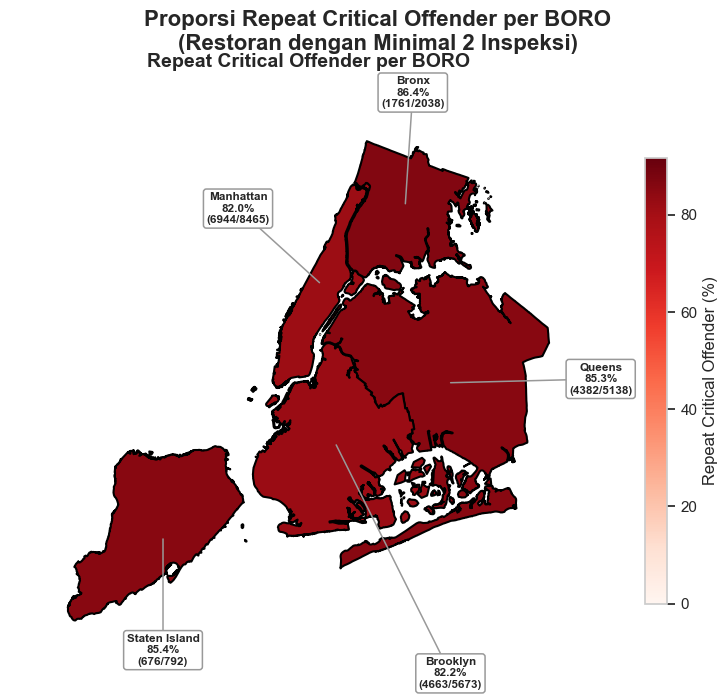

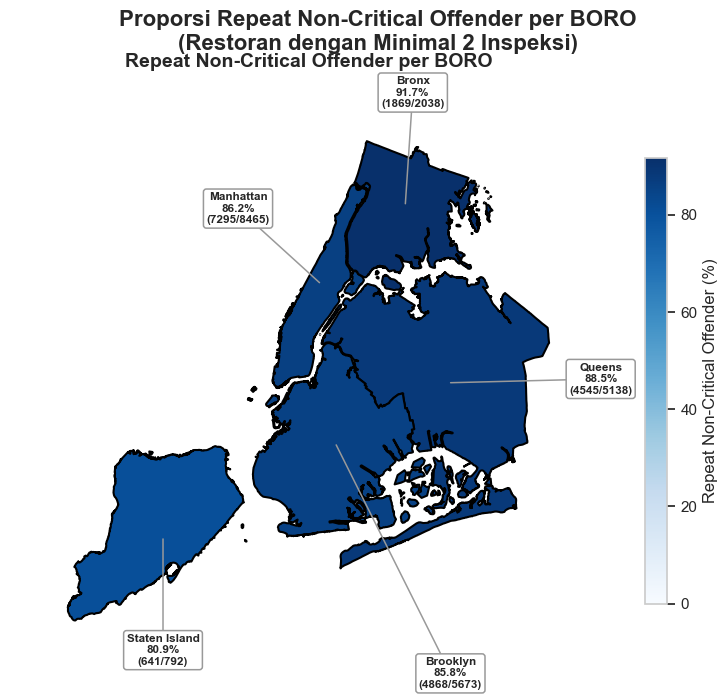

In [35]:
plot_gdf = map_gdf.to_crs(epsg=3857).copy()
label_gdf = plot_gdf.copy()
label_gdf["label_point"] = label_gdf.representative_point()

offsets = {
    "Bronx": (1000, 15000),
    "Manhattan": (-11000, 10000),
    "Queens": (20000, 500),
    "Brooklyn": (15000, -30000),
    "Staten Island": (0, -15000),
}

xmin, ymin, xmax, ymax = plot_gdf.total_bounds
pad_x = (xmax - xmin) * 0.12
pad_y = (ymax - ymin) * 0.12

global_vmax = max(
    plot_gdf["repeat_critical_pct"].max(),
    plot_gdf["repeat_noncritical_pct"].max()
)

def draw_map(ax, column, cmap, title, count_col, legend_label):
    ax.set_facecolor("white")

    plot_gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=1.5,
        edgecolor="black",
        legend=True,
        vmin=0,
        vmax=global_vmax,
        ax=ax,
        legend_kwds={
            "label": legend_label,
            "shrink": 0.75
        }
    )

    for _, row in label_gdf.iterrows():
        if pd.notna(row[column]):
            x, y = row["label_point"].x, row["label_point"].y
            dx, dy = offsets.get(row["BoroName"], (0, 0))

            ax.annotate(
                f"{row['BoroName']}\n{row[column]:.1f}%\n({int(row[count_col])}/{int(row['eligible_restaurants'])})",
                xy=(x, y),
                xytext=(x + dx, y + dy),
                fontsize=8.5,
                fontweight="bold",
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec="#999999",
                    lw=1.1
                ),
                arrowprops=dict(
                    arrowstyle="-",
                    color="#999999",
                    lw=1.1,
                    shrinkA=0,
                    shrinkB=4
                )
            )

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.axis("off")


# ===== Gambar 1: Repeat Critical Offender =====
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("white")

draw_map(
    ax,
    column="repeat_critical_pct",
    cmap="Reds",
    title="Repeat Critical Offender per BORO",
    count_col="repeat_critical_count",
    legend_label="Repeat Critical Offender (%)"
)

fig.suptitle(
    "Proporsi Repeat Critical Offender per BORO\n(Restoran dengan Minimal 2 Inspeksi)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()


# ===== Gambar 2: Repeat Non-Critical Offender =====
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("white")

draw_map(
    ax,
    column="repeat_noncritical_pct",
    cmap="Blues",
    title="Repeat Non-Critical Offender per BORO",
    count_col="repeat_noncritical_count",
    legend_label="Repeat Non-Critical Offender (%)"
)

fig.suptitle(
    "Proporsi Repeat Non-Critical Offender per BORO\n(Restoran dengan Minimal 2 Inspeksi)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

**Hotpoints per BORO**

In [36]:
geo_df = df_ins.dropna(subset=["Latitude", "Longitude", "SCORE"]).copy()

geo_df["Latitude"] = pd.to_numeric(geo_df["Latitude"], errors="coerce")
geo_df["Longitude"] = pd.to_numeric(geo_df["Longitude"], errors="coerce")
geo_df["SCORE"] = pd.to_numeric(geo_df["SCORE"], errors="coerce")
geo_df["BORO"] = geo_df["BORO"].replace("0", "Unknown")

geo_df = geo_df.dropna(subset=["Latitude", "Longitude", "SCORE"]).copy()

geo_df = geo_df[
    (geo_df["Latitude"].between(40.45, 40.95)) &
    (geo_df["Longitude"].between(-74.30, -73.65))
].copy()

high_score_threshold = geo_df["SCORE"].quantile(0.75)
df_hot = geo_df[geo_df["SCORE"] >= high_score_threshold].copy()

print(f"Threshold score tinggi (Q3): {high_score_threshold:.2f}")
print(f"Jumlah inspeksi score tinggi: {len(df_hot):,}")

min_score = df_hot["SCORE"].min()
max_score = df_hot["SCORE"].max()

if max_score == min_score:
    df_hot["weight"] = 1.0
else:
    df_hot["weight"] = 0.2 + 0.8 * (
        (df_hot["SCORE"] - min_score) / (max_score - min_score)
    )

heat_data = df_hot[["Latitude", "Longitude", "weight"]].values.tolist()

geojson_url = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
geojson_path = "boroughs.geojson"

response = requests.get(geojson_url)
response.raise_for_status()

with open(geojson_path, "wb") as f:
    f.write(response.content)

boro_gdf = gpd.read_file(geojson_path)

boro_stats = (
    df_hot[df_hot["BORO"].notna() & (df_hot["BORO"] != "Unknown")]
    .groupby("BORO", as_index=False)
    .agg(
        hotspot_count=("SCORE", "count"),
        mean_score=("SCORE", "mean"),
        median_score=("SCORE", "median"),
        max_score=("SCORE", "max")
    )
)

map_gdf = boro_gdf.merge(
    boro_stats,
    left_on="BoroName",
    right_on="BORO",
    how="left"
)

center_lat = geo_df["Latitude"].median()
center_lon = geo_df["Longitude"].median()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

HeatMap(
    heat_data,
    radius=18,
    blur=14,
    max_zoom=13,
    min_opacity=0.35,
    name="Hotspot Score Tinggi"
).add_to(m)

folium.GeoJson(
    map_gdf,
    name="BORO Boundary",
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "#444444",
        "weight": 1.5,
        "fillOpacity": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["BoroName", "hotspot_count", "mean_score", "median_score", "max_score"],
        aliases=["BORO", "Jumlah hotspot", "Mean score", "Median score", "Max score"],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: white;
            color: #333333;
            font-family: Arial;
            font-size: 12px;
            padding: 8px;
            border: 1px solid #999;
            border-radius: 4px;
        """
    )
).add_to(m)

label_gdf = map_gdf.to_crs(epsg=3857).copy()
label_gdf["label_point"] = label_gdf.representative_point()
label_gdf = label_gdf.to_crs(epsg=4326)

for _, row in label_gdf.iterrows():
    if pd.notna(row["BoroName"]):
        folium.Marker(
            location=[row["label_point"].y, row["label_point"].x],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size: 11px;
                    font-weight: bold;
                    color: black;
                    background: rgba(255,255,255,0.85);
                    padding: 2px 6px;
                    border-radius: 4px;
                    border: 1px solid #888;
                    white-space: nowrap;
                ">
                    {row['BoroName']}
                </div>
                """
            )
        ).add_to(m)

top_points = (
    df_hot.sort_values("SCORE", ascending=False)
    .head(203)  
    .copy()
)

for _, row in top_points.iterrows():
    popup_html = f"""
    <b>DBA:</b> {row.get('DBA', 'N/A')}<br>
    <b>BORO:</b> {row.get('BORO', 'N/A')}<br>
    <b>Cuisine:</b> {row.get('CUISINE DESCRIPTION', 'N/A')}<br>
    <b>Score:</b> {row.get('SCORE', 'N/A')}<br>
    <b>Inspection Date:</b> {row.get('INSPECTION DATE', 'N/A')}<br>
    <b>Inspection Type:</b> {row.get('INSPECTION TYPE', 'N/A')}
    """

    tooltip_text = f"{row.get('BORO', 'N/A')} | Score: {row.get('SCORE', 'N/A')}"

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        color="#8b0000",
        weight=1,
        fill=True,
        fill_color="#b22222",
        fill_opacity=0.75,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m.save("heatmap_hotspot_score_tinggi_dengan_label.html")

display(HTML(m._repr_html_()))
print("Peta berhasil disimpan sebagai: heatmap_hotspot_score_tinggi_dengan_label.html")

Threshold score tinggi (Q3): 24.00
Jumlah inspeksi score tinggi: 17,979


Peta berhasil disimpan sebagai: heatmap_hotspot_score_tinggi_dengan_label.html


Threshold score tinggi (Q3): 24.00
Jumlah inspeksi score tinggi: 17,979


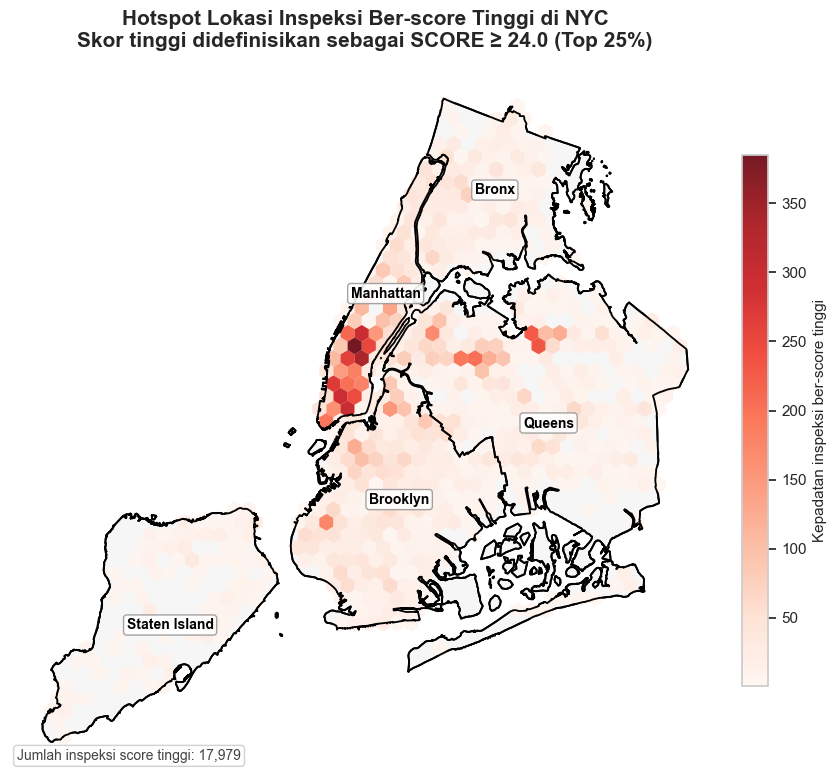

In [37]:
geo_df = df_ins.dropna(subset=["Latitude", "Longitude", "SCORE"]).copy()

geo_df["Latitude"] = pd.to_numeric(geo_df["Latitude"], errors="coerce")
geo_df["Longitude"] = pd.to_numeric(geo_df["Longitude"], errors="coerce")
geo_df["SCORE"] = pd.to_numeric(geo_df["SCORE"], errors="coerce")
geo_df["BORO"] = geo_df["BORO"].replace("0", "Unknown")

geo_df = geo_df.dropna(subset=["Latitude", "Longitude", "SCORE"]).copy()

geo_df = geo_df[
    (geo_df["Latitude"].between(40.45, 40.95)) &
    (geo_df["Longitude"].between(-74.30, -73.65))
].copy()

high_score_threshold = geo_df["SCORE"].quantile(0.75)
df_hot = geo_df[geo_df["SCORE"] >= high_score_threshold].copy()

print(f"Threshold score tinggi (Q3): {high_score_threshold:.2f}")
print(f"Jumlah inspeksi score tinggi: {len(df_hot):,}")

geojson_url = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
geojson_path = "boroughs.geojson"

response = requests.get(geojson_url)
response.raise_for_status()

with open(geojson_path, "wb") as f:
    f.write(response.content)

boro_gdf = gpd.read_file(geojson_path)

points_gdf = gpd.GeoDataFrame(
    df_hot,
    geometry=gpd.points_from_xy(df_hot["Longitude"], df_hot["Latitude"]),
    crs="EPSG:4326"
)

boro_plot = boro_gdf.to_crs(epsg=3857).copy()
points_plot = points_gdf.to_crs(epsg=3857).copy()

label_gdf = boro_plot.copy()
label_gdf["label_point"] = label_gdf.representative_point()

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

boro_plot.plot(
    ax=ax,
    color="#f6f6f6",
    edgecolor="black",
    linewidth=1.4
)

hb = ax.hexbin(
    points_plot.geometry.x,
    points_plot.geometry.y,
    gridsize=45,
    cmap="Reds",
    mincnt=1,
    linewidths=0,
    alpha=0.9
)

boro_plot.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.3
)

for _, row in label_gdf.iterrows():
    x, y = row["label_point"].x, row["label_point"].y
    ax.text(
        x, y,
        row["BoroName"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="#999999",
            alpha=0.9
        )
    )
    
cbar = fig.colorbar(hb, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Kepadatan inspeksi ber-score tinggi", fontsize=11)

ax.set_title(
    "Hotspot Lokasi Inspeksi Ber-score Tinggi di NYC\n"
    f"Skor tinggi didefinisikan sebagai SCORE ≥ {high_score_threshold:.1f} (Top 25%)",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.text(
    0.01, 0.02,
    f"Jumlah inspeksi score tinggi: {len(df_hot):,}",
    transform=ax.transAxes,
    fontsize=10,
    color="#444444",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9
    )
)

ax.axis("off")
plt.tight_layout()
plt.show()

# Hasil Exploratory Data Analysis (EDA)

## Gambaran Umum

Exploratory Data Analysis (EDA) dilakukan pada data inspeksi restoran di New York City (NYC) untuk periode **3 tahun terakhir**. Analisis ini bertujuan untuk memahami pola distribusi `SCORE`, faktor-faktor yang berkaitan dengan tingginya nilai inspeksi, karakteristik pelanggaran berdasarkan wilayah, jenis cuisine, dan tipe inspeksi, serta pola pengulangan pelanggaran dan persebaran spasial inspeksi dengan score tinggi.

Secara umum, analisis menunjukkan bahwa sebagian besar restoran memiliki tingkat pelanggaran rendah hingga menengah, namun terdapat kelompok tertentu yang secara konsisten menunjukkan score lebih tinggi dan kecenderungan pelanggaran berulang.

---

## 1. Feature Correlation

Heatmap korelasi menunjukkan bahwa tidak semua fitur numerik dalam dataset memberikan informasi yang benar-benar berbeda. Beberapa fitur memiliki hubungan yang sangat kuat, sehingga berpotensi merepresentasikan informasi yang saling tumpang tindih.

**Insight:**
- `SCORE` memiliki korelasi yang sangat kuat dengan `violation_count` dan `critical_count`. Hal ini menunjukkan bahwa semakin banyak pelanggaran yang ditemukan, terutama pelanggaran critical, maka score inspeksi cenderung semakin tinggi.
- `violation_count` dan `critical_count` juga memiliki korelasi kuat, yang menunjukkan bahwa keduanya sama-sama mencerminkan tingkat keparahan hasil inspeksi.
- Fitur administratif dan wilayah seperti `ZIPCODE`, `Community_Board`, `BIN`, dan `BBL` menunjukkan korelasi tinggi satu sama lain, sehingga mengindikasikan adanya kemungkinan redundansi fitur.
- `Latitude` dan `Longitude` juga saling berkaitan erat, tetapi keduanya lebih tepat dimanfaatkan untuk analisis spasial daripada digunakan sebagai fitur numerik biasa.
- Temuan ini menunjukkan bahwa pada tahap modeling, tidak semua fitur numerik perlu digunakan secara bersamaan karena sebagian di antaranya membawa informasi yang serupa.

---

## 2. Distribusi SCORE Inspeksi

Distribusi `SCORE` menunjukkan pola **right-skewed**, di mana sebagian besar inspeksi berada pada rentang score rendah hingga menengah, sementara hanya sebagian kecil yang memiliki score sangat tinggi.

**Insight:**
- Mayoritas restoran memiliki score pada kisaran rendah, yang menunjukkan bahwa secara umum kondisi sanitasi restoran di NYC relatif terkendali.
- Distribusi yang condong ke kanan menunjukkan adanya sejumlah kecil restoran dengan kondisi pelanggaran yang jauh lebih berat dibanding mayoritas lainnya.
- Nilai mean yang lebih tinggi daripada median mengindikasikan keberadaan outlier, yaitu inspeksi dengan score sangat tinggi.
- Dengan demikian, distribusi ini memperlihatkan bahwa meskipun sebagian besar restoran tidak berada pada kondisi buruk, terdapat kelompok kecil yang memerlukan perhatian lebih serius.

---

## 3. Perubahan Tren SCORE dari Waktu ke Waktu

Analisis tren bulanan memperlihatkan bahwa median score cenderung lebih stabil dibandingkan mean score. Hal ini menunjukkan bahwa kondisi umum restoran relatif konsisten dari waktu ke waktu, tetapi tetap ada kasus-kasus ekstrem yang memengaruhi rata-rata.

**Insight:**
- Median bulanan yang stabil menunjukkan bahwa kondisi tipikal restoran tidak banyak berubah dari bulan ke bulan.
- Mean bulanan yang lebih fluktuatif menandakan adanya inspeksi dengan score tinggi yang cukup memengaruhi rata-rata.
- Dengan demikian, median lebih representatif dibanding mean untuk menggambarkan kondisi umum inspeksi restoran.
- Fluktuasi yang muncul menunjukkan bahwa perubahan tren lebih banyak didorong oleh kasus-kasus ekstrem daripada perubahan pada mayoritas restoran.

---

## 4. Perbedaan SCORE antar BORO

Analisis berdasarkan `BORO` menunjukkan bahwa terdapat perbedaan rata-rata score antarwilayah, meskipun median score antar BORO relatif mirip.

**Insight:**
- **Queens** memiliki mean score tertinggi, sedangkan **Staten Island** memiliki mean score terendah.
- Mean score antar BORO bervariasi pada rentang 17-20
- Hal ini menunjukkan bahwa perbedaan antarwilayah lebih banyak dipengaruhi oleh keberadaan kasus-kasus ekstrem daripada perbedaan kondisi mayoritas restoran.
- Dengan kata lain, kondisi tipikal restoran di tiap BORO relatif mirip, namun beberapa wilayah memiliki lebih banyak inspeksi dengan score yang sangat tinggi.

---

## 5. Cuisine dengan Score Tertinggi

Analisis berdasarkan `CUISINE DESCRIPTION` menunjukkan bahwa beberapa jenis cuisine memiliki median score inspeksi yang lebih tinggi dibanding yang lain.

**Insight:**
- **Indian** muncul sebagai cuisine dengan median score tertinggi pada hasil analisis notebook.
- Secara umum, beberapa cuisine dari kelompok Asia Selatan dan Asia cenderung mendominasi daftar cuisine dengan score tinggi.
- Hal ini menunjukkan bahwa jenis cuisine dapat menjadi salah satu indikator penting dalam melihat pola risiko inspeksi.
- Meskipun demikian, ukuran sampel tetap perlu diperhatikan agar interpretasi tidak bias pada cuisine dengan jumlah inspeksi yang kecil.

---

## 6. SCORE berdasarkan Inspection Type

Setiap tipe inspeksi menunjukkan pola score yang berbeda, sehingga konteks inspeksi turut memengaruhi tingkat pelanggaran yang ditemukan.

**Insight:**
- **Non-operational initial inspection** memiliki mean score tertinggi dibanding tipe inspeksi lainnya.
- Pada kelompok inspeksi operasional, **compliance inspection** cenderung menghasilkan score lebih tinggi dibanding inspeksi rutin.
- **Cycle inspection** sebagai inspeksi berkala cenderung memiliki score lebih rendah.
- Hal ini menunjukkan bahwa tipe inspeksi memiliki hubungan yang cukup signifikan dengan tingkat pelanggaran yang ditemukan.

---

## 7. Violation Code yang Paling Sering Muncul

Tidak semua violation code memiliki frekuensi kemunculan yang sama. Beberapa kode muncul jauh lebih dominan dibanding lainnya.

**Insight:**
- Secara keseluruhan, **10F** merupakan violation code yang paling sering muncul.
- Pada kategori critical violation, **06D** termasuk kode yang paling dominan ditemukan.
- Temuan ini menunjukkan bahwa terdapat jenis pelanggaran tertentu yang secara konsisten menjadi masalah utama dalam inspeksi restoran.
- Kode-kode tersebut penting untuk diperhatikan karena dapat menjadi prioritas dalam upaya pengawasan dan perbaikan.

---

## 8. Violation Code yang Berkaitan dengan SCORE Tinggi

Selain frekuensinya, analisis juga menunjukkan bahwa tidak semua violation code memiliki hubungan yang sama terhadap tingginya score inspeksi.

**Insight:**
- Pada hasil notebook, **05F** termasuk violation code yang paling terkait dengan median score tinggi.
- Mayoritas kode dalam kelompok ini didominasi oleh critical violation, sehingga menunjukkan bahwa pelanggaran critical sangat erat kaitannya dengan hasil inspeksi yang buruk.
- Temuan ini menunjukkan bahwa jenis violation tertentu dapat menjadi sinyal awal untuk mengidentifikasi restoran dengan profil risiko tinggi.
- Dengan demikian, analisis violation code tidak hanya penting dari sisi frekuensi, tetapi juga dari sisi dampaknya terhadap score inspeksi.

---

## 9. Hubungan Jumlah Critical Violation dengan SCORE

Jumlah critical violation menunjukkan hubungan yang sangat jelas dengan kenaikan score inspeksi.

**Insight:**
- Semakin banyak critical violation dalam satu inspeksi, semakin tinggi pula score inspeksinya.
- Pola kenaikannya cenderung linear, sehingga jumlah critical violation dapat dianggap sebagai indikator kuat tingkat keparahan inspeksi.
- Pada kelompok dengan jumlah critical violation sangat tinggi, terlihat adanya lonjakan score yang lebih ekstrem.
- Hal ini menegaskan bahwa pelanggaran critical merupakan komponen utama yang membedakan inspeksi ringan dan inspeksi berat.

---

## 10. Proporsi Repeat Offender

Analisis repeat offender menunjukkan bahwa pelanggaran restoran sering kali bersifat berulang, bukan hanya kejadian satu kali.

**Insight:**
- Sebagian besar restoran dalam data tergolong **repeat offender**, yaitu pernah mendapatkan critical violation lebih dari satu kali dalam periode 3 tahun terakhir.
- Temuan ini menunjukkan bahwa banyak restoran belum melakukan perbaikan yang benar-benar tuntas setelah inspeksi sebelumnya.
- Dengan kata lain, tantangan utama dalam data ini bukan hanya keberadaan pelanggaran, tetapi juga keberlanjutan masalah dari waktu ke waktu.
- Tingginya repeat offender menunjukkan perlunya pendekatan pengawasan yang lebih terarah pada restoran dengan riwayat pelanggaran berulang.

---

## 11. Violation Code dengan Repeat Rate Tertinggi

Analisis lanjutan menunjukkan bahwa beberapa violation code memiliki kecenderungan tinggi untuk muncul kembali pada restoran yang sama.

**Insight:**
- **10F** menjadi violation code dengan repeat rate tertinggi.
- Beberapa kode lain juga menunjukkan tingkat pengulangan yang tinggi, baik pada kategori critical maupun non-critical.
- Hal ini menandakan bahwa sejumlah pelanggaran tidak hanya sering muncul, tetapi juga sulit diperbaiki secara permanen.
- Dengan demikian, jenis violation tertentu dapat dianggap sebagai pelanggaran yang persisten dan membutuhkan perhatian lebih serius.

---

## 12. Cuisine dengan Repeat Offender Tertinggi

Jika repeat offender dilihat berdasarkan cuisine, terdapat beberapa kelompok cuisine yang menunjukkan tingkat pengulangan pelanggaran yang sangat tinggi.

**Insight:**
- Cuisine seperti **Indian**, **Southeast Asian**, **Bangladeshi**, dan **Peruvian** menunjukkan proporsi repeat offender yang tinggi.
- **Chinese** juga menonjol karena memiliki jumlah restoran besar sekaligus tingkat repeat offender yang tinggi.
- Temuan ini menunjukkan bahwa pada beberapa cuisine, masalah kepatuhan tidak hanya tinggi sekali waktu, tetapi juga cenderung berulang secara konsisten.
- Oleh karena itu, cuisine dapat digunakan sebagai salah satu dimensi segmentasi risiko pengawasan.

---

## 13. Repeat Offender per BORO

Pola repeat offender juga terlihat berbeda ketika dianalisis berdasarkan BORO.

**Insight:**
- **Bronx** memiliki proporsi repeat critical offender tertinggi.
- **Queens** juga menunjukkan tingkat repeat offender yang relatif tinggi.
- Manhattan memiliki jumlah repeat offender yang besar, tetapi secara proporsi tidak setinggi Bronx.
- Temuan ini menunjukkan bahwa masalah pengulangan pelanggaran tidak hanya ditentukan oleh banyaknya restoran di suatu wilayah, tetapi juga oleh tingkat konsistensi pelanggaran di wilayah tersebut.

---

## 14. Hotspot Lokasi Inspeksi dengan SCORE Tinggi

Analisis spasial menunjukkan bahwa inspeksi dengan score tinggi tidak tersebar merata, melainkan cenderung terkonsentrasi di area-area tertentu di NYC.

**Insight:**
- Pada notebook, inspeksi dengan score tinggi didefinisikan sebagai inspeksi dengan **SCORE ≥ 24**, yaitu kelompok **top 10%** score tertinggi.
- Terdapat sekitar **17.979 inspeksi** yang masuk ke kategori ini.
- Dari peta interaktif dan hexbin, **Manhattan** terlihat sebagai wilayah dengan kepadatan hotspot paling tinggi.
- **Queens** dan sebagian **Brooklyn** juga menunjukkan konsentrasi hotspot, tetapi tidak sepadat Manhattan.
- Hal ini menunjukkan bahwa inspeksi berat tidak tersebar secara acak, melainkan cenderung terkonsentrasi pada area tertentu yang dapat menjadi prioritas pengawasan.

---

# Kesimpulan Umum EDA

Secara keseluruhan, hasil EDA menunjukkan bahwa sebagian besar restoran di NYC berada pada tingkat pelanggaran rendah hingga menengah, namun terdapat kelompok tertentu yang secara konsisten memiliki score lebih tinggi. Faktor yang paling kuat berkaitan dengan tingginya score inspeksi adalah jumlah violation, terutama **critical violation**. Selain itu, pola pelanggaran dalam dataset ini juga menunjukkan sifat yang persisten, karena banyak restoran dan violation code yang berulang dari waktu ke waktu.

**Poin utama yang dapat disimpulkan adalah sebagai berikut:**
- Distribusi `SCORE` bersifat right-skewed, dengan mayoritas restoran berada pada level pelanggaran rendah hingga menengah.
- `critical_count` dan `violation_count` merupakan faktor yang paling kuat berkaitan dengan tingginya score inspeksi.
- Queens memiliki mean score tertinggi, tetapi kepadatan hotspot score tinggi paling menonjol terlihat di Manhattan.
- Beberapa cuisine menunjukkan risiko score tinggi dan repeat offender yang lebih besar dibanding yang lain.
- Tantangan utama dalam data ini bukan hanya banyaknya pelanggaran, tetapi juga **pengulangan pelanggaran dari waktu ke waktu**.